# Assignment 2: From Trees to Neural Networks
## Home Credit Default Risk — GBDT vs MLP Comparison

**Dataset**: [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk)
**Objective**: Predict loan default (binary classification, TARGET=1, ~8% positive).
**Models**: XGBoost (GBDT) vs scikit-learn MLPClassifier (MLP).

Key challenges:
- **Severe class imbalance** (~8% default) — accuracy is misleading; we use **AUC-PR** as the primary metric
- **122 application features** + 6 supplementary behavioral/credit history tables (70M+ total rows)
- **Extensive missing data**: 18 features >60% missing; key predictors partially missing
- **Mixed types**: 16 categorical, 106 numeric features

All preprocessing (imputation, encoding, scaling) is fit exclusively on the training partition to prevent data leakage.

---
## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import time, gc, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
DATA_DIR = 'home-credit-default-risk/'

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
})
sns.set_style('whitegrid')
C0, C1 = '#2196F3', '#F44336'
print("Setup complete.")

Setup complete.


---
## 2. Data Loading & First Look

We load all seven data files. The primary table (`application_train`) contains the target and
121 application-level features. Six supplementary tables provide historical credit bureau records,
previous Home Credit applications, POS/cash loan status, credit card balances, and installment
payment history. These will be aggregated per applicant in Section 5 (Feature Engineering).

Supplementary table aggregations (counts, sums, means of historical behavior) are computed
on the full table and merged by `SK_ID_CURR`. This is **not** data leakage — these features
represent historical facts available at application time and do not incorporate the target.

In [2]:
app = pd.read_csv(DATA_DIR + 'application_train.csv')
bureau = pd.read_csv(DATA_DIR + 'bureau.csv')
bb = pd.read_csv(DATA_DIR + 'bureau_balance.csv')
prev = pd.read_csv(DATA_DIR + 'previous_application.csv')
pos = pd.read_csv(DATA_DIR + 'POS_CASH_balance.csv')
cc = pd.read_csv(DATA_DIR + 'credit_card_balance.csv')
inst = pd.read_csv(DATA_DIR + 'installments_payments.csv')

print("Table shapes:")
for name, tbl in [('application_train', app), ('bureau', bureau),
                   ('bureau_balance', bb), ('previous_application', prev),
                   ('POS_CASH_balance', pos), ('credit_card_balance', cc),
                   ('installments_payments', inst)]:
    print(f"  {name:25s} {tbl.shape[0]:>12,} rows x {tbl.shape[1]:>3} cols")
print()
print("Target distribution:")
for v, lbl in [(0, 'No Default'), (1, 'Default')]:
    n = (app['TARGET'] == v).sum()
    print(f"  {lbl:12s} (TARGET={v}): {n:>7,}  ({n/len(app):.2%})")
print()
print("Dtype breakdown:")
print(app.dtypes.value_counts().to_frame('count').to_string())

Table shapes:
  application_train              307,511 rows x 122 cols
  bureau                       1,716,428 rows x  17 cols
  bureau_balance              27,299,925 rows x   3 cols
  previous_application         1,670,214 rows x  37 cols
  POS_CASH_balance            10,001,358 rows x   8 cols
  credit_card_balance          3,840,312 rows x  23 cols
  installments_payments       13,605,401 rows x   8 cols

Target distribution:
  No Default   (TARGET=0): 282,686  (91.93%)
  Default      (TARGET=1):  24,825  (8.07%)

Dtype breakdown:
         count
float64     65
int64       41
object      16


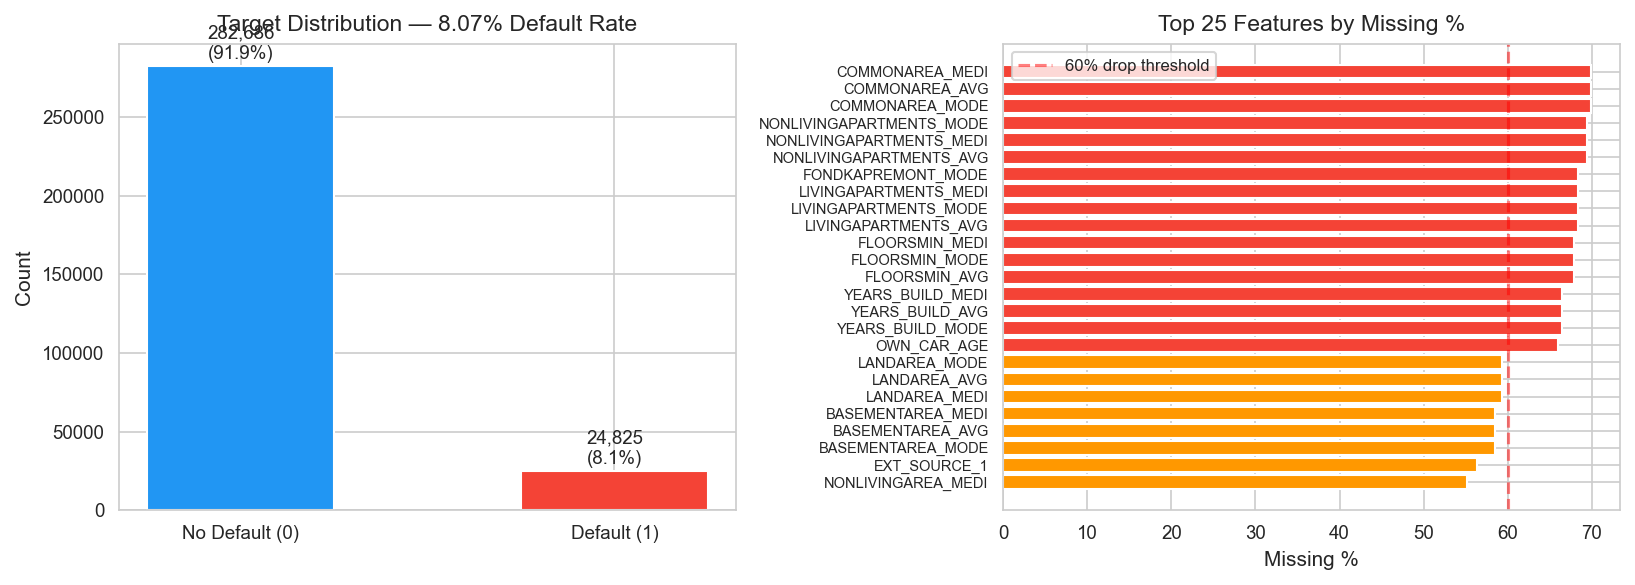

Columns with >60% missing (will drop): 17
Columns with 0 < missing <= 60%:       50
Columns with no missing:               55


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# -- Left: target distribution --
counts = app['TARGET'].value_counts().sort_index()
bars = axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
                    color=[C0, C1], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}\n({val/len(app):.1%})', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution — 8.07% Default Rate')

# -- Right: missing values top-25 --
miss_pct = (app.isnull().sum() / len(app) * 100).sort_values(ascending=True)
top25 = miss_pct[miss_pct > 0].tail(25)
colors = ['#F44336' if v > 60 else '#FF9800' if v > 30 else '#78909C' for v in top25.values]
axes[1].barh(range(len(top25)), top25.values, color=colors)
axes[1].set_yticks(range(len(top25)))
axes[1].set_yticklabels(top25.index, fontsize=7)
axes[1].set_xlabel('Missing %')
axes[1].set_title('Top 25 Features by Missing %')
axes[1].axvline(x=60, color='red', ls='--', alpha=0.5, label='60% drop threshold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_01_target_and_missing.png', bbox_inches='tight')
plt.show()

print(f"Columns with >60% missing (will drop): {(miss_pct > 60).sum()}")
print(f"Columns with 0 < missing <= 60%:       {((miss_pct > 0) & (miss_pct <= 60)).sum()}")
print(f"Columns with no missing:               {(miss_pct == 0).sum()}")

**Key observations:**
- **Severe class imbalance**: only 8.07% of applicants defaulted. A naive "predict 0 always" model
  achieves 91.9% accuracy — making **accuracy a misleading metric**. We adopt **AUC-PR (Average Precision)**
  as the primary evaluation metric because it directly measures the precision-recall trade-off
  for the minority (default) class.
- **18 features exceed 60% missing** (apartment-block descriptors: `COMMONAREA_*`,
  `NONLIVINGAPARTMENTS_*`, `LIVINGAPARTMENTS_*`, `FLOORSMIN_*`, `YEARS_BUILD_*`, `OWN_CAR_AGE`).
  Imputing these would be mostly fabrication — we drop them.
- **Key predictors are partially missing**: `EXT_SOURCE_1` (56%), `EXT_SOURCE_3` (20%) — these
  external credit scores have the strongest individual correlations with TARGET, so we keep them
  and impute with the median. For `EXT_SOURCE_1`, we also create a binary missingness indicator.

---
## 3. Exploratory Data Analysis

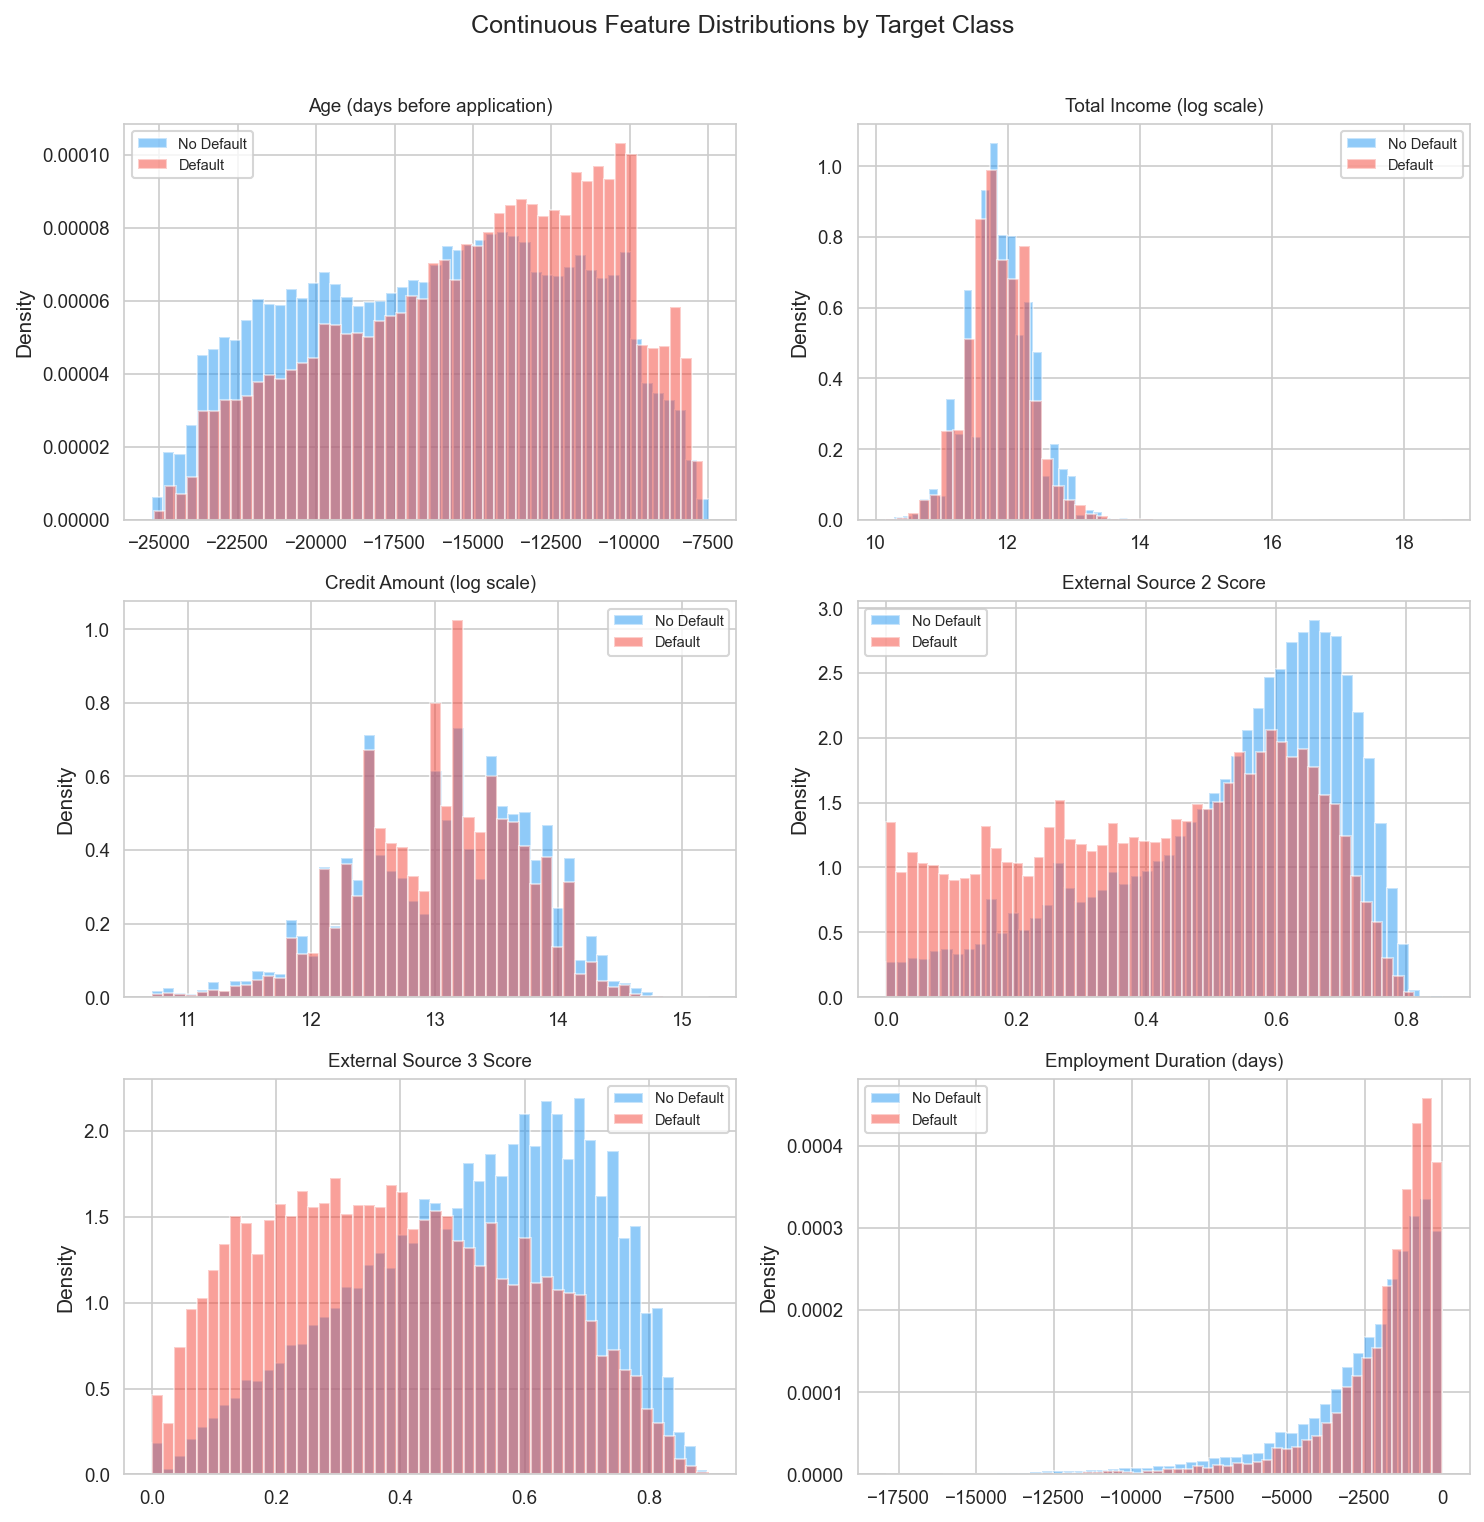

In [4]:
# 3.1 Continuous feature distributions by target class
eda_features = [
    ('DAYS_BIRTH',       'Age (days before application)', False, None),
    ('AMT_INCOME_TOTAL', 'Total Income (log scale)',      True,  None),
    ('AMT_CREDIT',       'Credit Amount (log scale)',     True,  None),
    ('EXT_SOURCE_2',     'External Source 2 Score',       False, None),
    ('EXT_SOURCE_3',     'External Source 3 Score',       False, None),
    ('DAYS_EMPLOYED',    'Employment Duration (days)',    False, 365243),
]

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for i, (col, title, use_log, anomaly_val) in enumerate(eda_features):
    ax = axes[i]
    data = app[[col, 'TARGET']].dropna()
    if anomaly_val is not None:
        data = data[data[col] != anomaly_val]
    vals = data[col].copy()
    if use_log:
        vals = np.log1p(vals.clip(lower=0))
    for cls, color, label in [(0, C0, 'No Default'), (1, C1, 'Default')]:
        subset = vals[data['TARGET'] == cls]
        ax.hist(subset, bins=50, color=color, alpha=0.5, density=True, label=label)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')

plt.suptitle('Continuous Feature Distributions by Target Class', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_continuous_distributions.png', bbox_inches='tight')
plt.show()

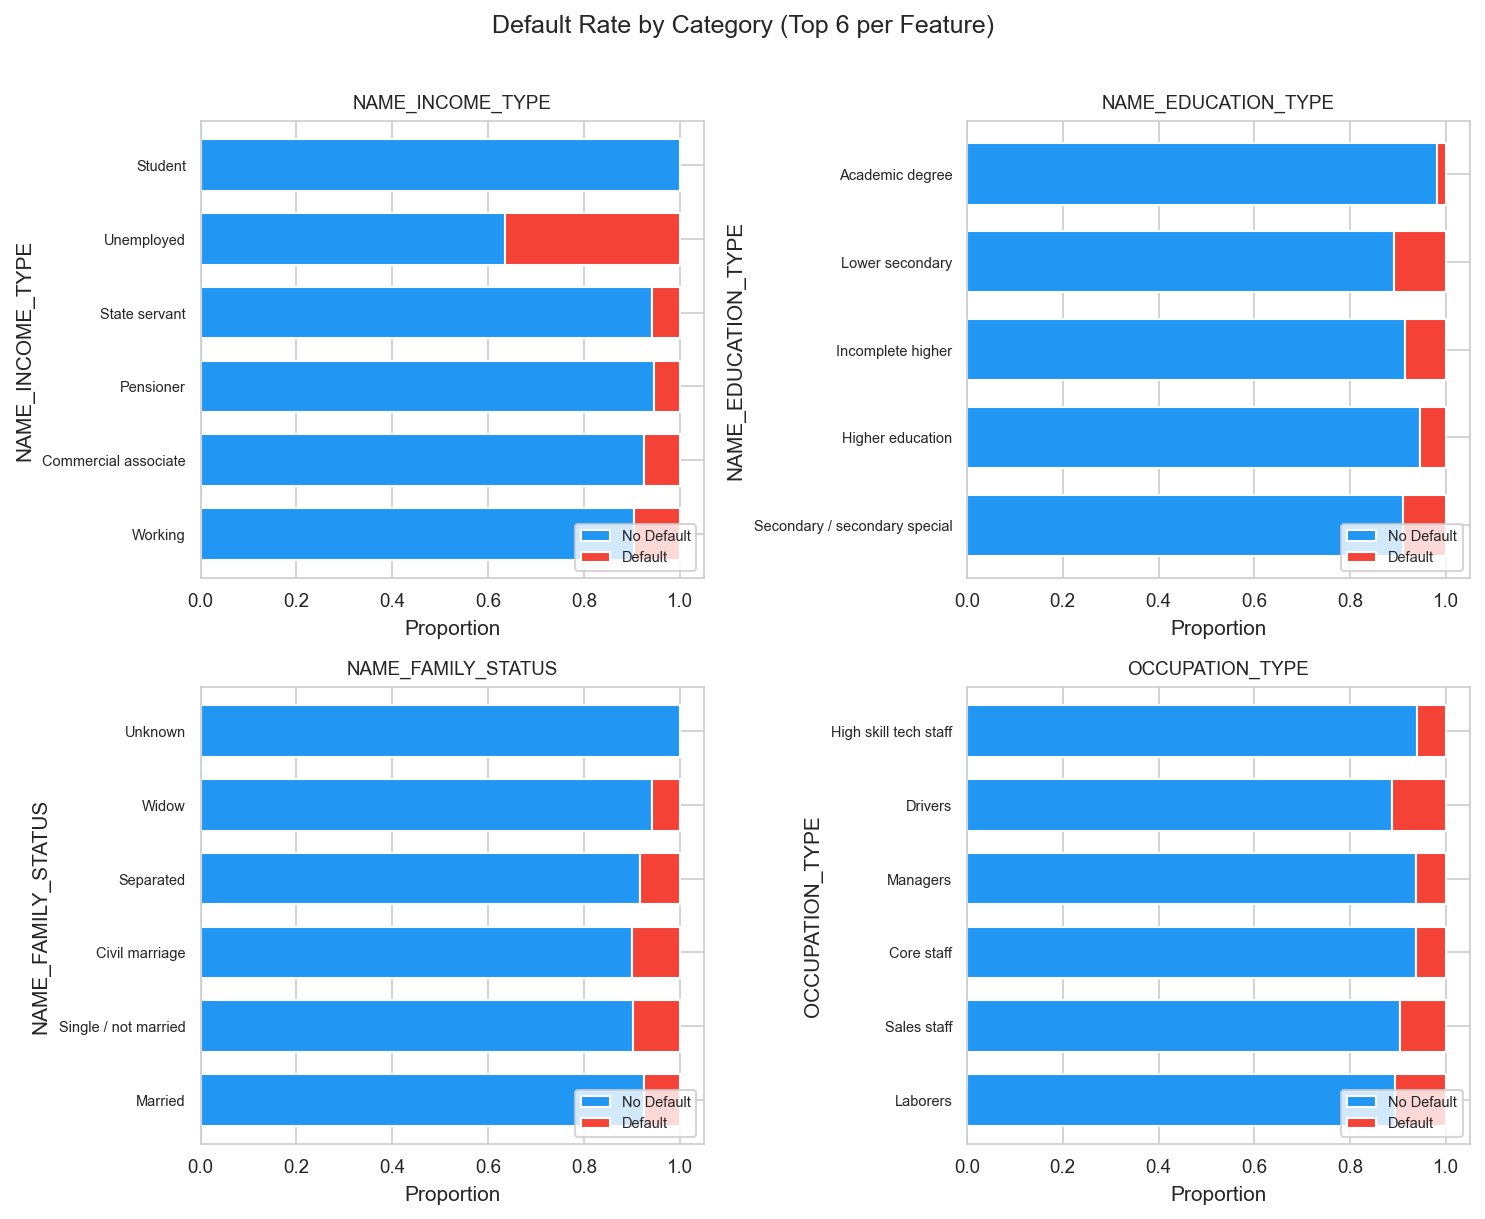

In [5]:
# 3.2 Categorical feature distributions — default rate by category
cat_eda = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
           'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cat_eda):
    data = app[[col, 'TARGET']].dropna()
    top_cats = data[col].value_counts().head(6).index
    data = data[data[col].isin(top_cats)]
    ct = pd.crosstab(data[col], data['TARGET'], normalize='index').reindex(top_cats)
    ct.plot(kind='barh', stacked=True, ax=axes[i], color=[C0, C1], width=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Proportion')
    axes[i].legend(['No Default', 'Default'], fontsize=7, loc='lower right')
    axes[i].tick_params(axis='y', labelsize=7)

plt.suptitle('Default Rate by Category (Top 6 per Feature)', y=1.01)
plt.tight_layout()
plt.savefig('fig_03_categorical_distributions.png', bbox_inches='tight')
plt.show()

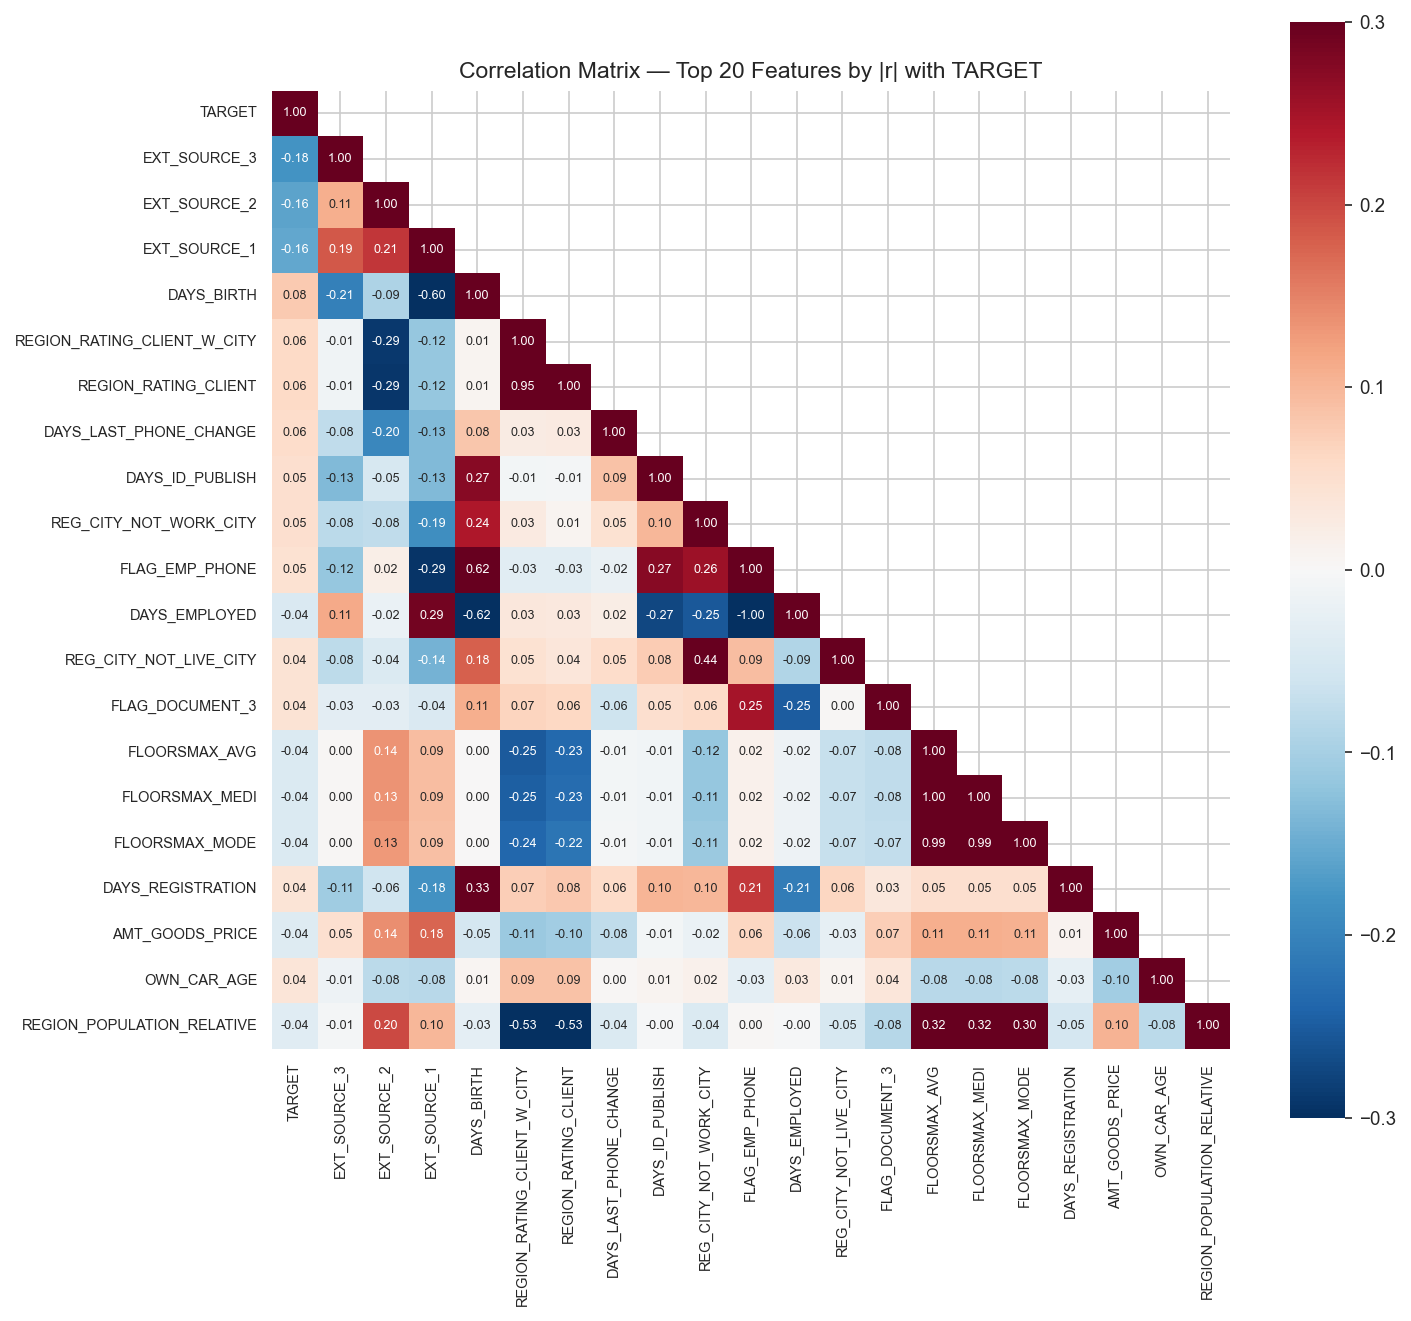

Top 10 correlations with TARGET:
                                  |r|
EXT_SOURCE_3                 0.178919
EXT_SOURCE_2                 0.160472
EXT_SOURCE_1                 0.155317
DAYS_BIRTH                   0.078239
REGION_RATING_CLIENT_W_CITY  0.060893
REGION_RATING_CLIENT         0.058899
DAYS_LAST_PHONE_CHANGE       0.055218
DAYS_ID_PUBLISH              0.051457
REG_CITY_NOT_WORK_CITY       0.050994
FLAG_EMP_PHONE               0.045982


In [6]:
# 3.3 Correlation heatmap — top 20 features by |r| with TARGET
num_cols_all = app.select_dtypes(include=[np.number]).columns.drop(['SK_ID_CURR', 'TARGET'])
corr_target = app[num_cols_all].corrwith(app['TARGET']).abs().sort_values(ascending=False)
top20 = corr_target.head(20).index.tolist()

corr_matrix = app[['TARGET'] + top20].corr()

fig, ax = plt.subplots(figsize=(10, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.3, vmax=0.3, ax=ax,
            annot_kws={'fontsize': 6}, square=True)
ax.set_title('Correlation Matrix — Top 20 Features by |r| with TARGET')
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.savefig('fig_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("Top 10 correlations with TARGET:")
print(corr_target.head(10).to_frame('|r|').to_string())

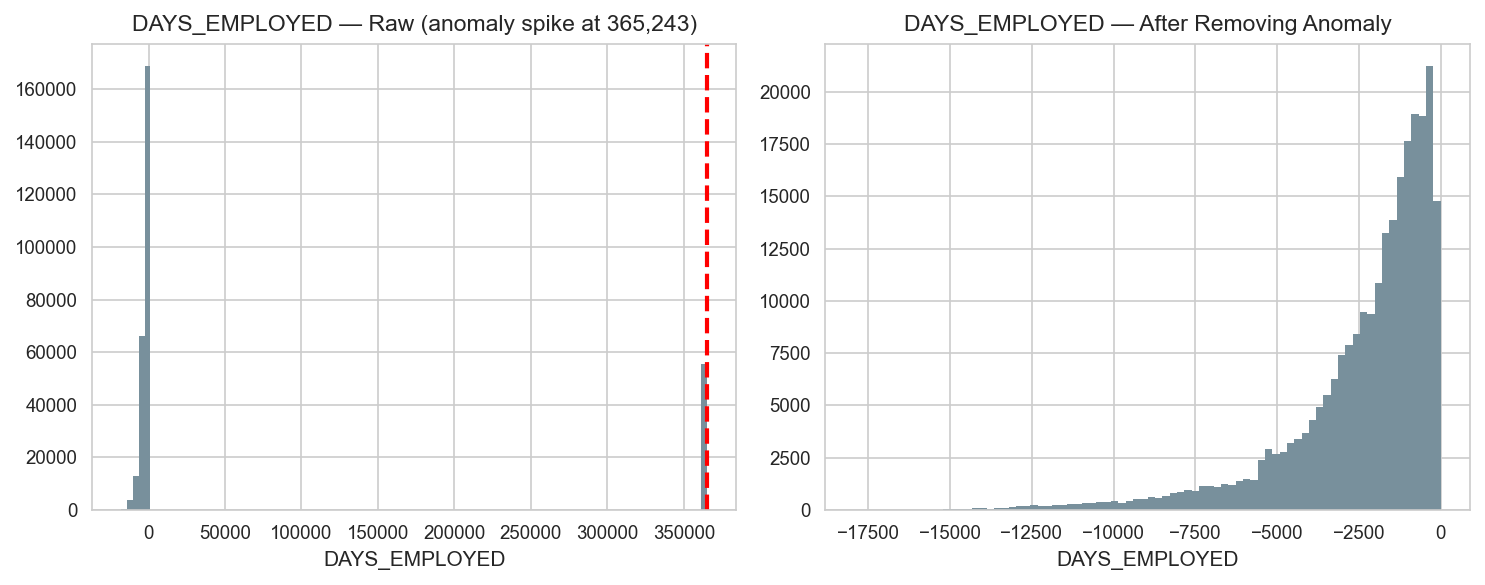

Anomalous rows (365,243): 55,374  — default rate 5.40%
Normal rows:              252,137  — default rate 8.66%
The anomalous group has a LOWER default rate, suggesting these are
pensioners or unemployed applicants coded with a sentinel value.


In [7]:
# 3.4 DAYS_EMPLOYED anomaly visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(app['DAYS_EMPLOYED'], bins=100, color='#78909C', edgecolor='none')
axes[0].axvline(x=365243, color='red', ls='--', lw=2)
axes[0].set_title('DAYS_EMPLOYED — Raw (anomaly spike at 365,243)')
axes[0].set_xlabel('DAYS_EMPLOYED')

clean_emp = app.loc[app['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED']
axes[1].hist(clean_emp, bins=80, color='#78909C', edgecolor='none')
axes[1].set_title('DAYS_EMPLOYED — After Removing Anomaly')
axes[1].set_xlabel('DAYS_EMPLOYED')

plt.tight_layout()
plt.savefig('fig_05_days_employed_anomaly.png', bbox_inches='tight')
plt.show()

n_anom = (app['DAYS_EMPLOYED'] == 365243).sum()
rate_anom = app.loc[app['DAYS_EMPLOYED'] == 365243, 'TARGET'].mean()
rate_norm = app.loc[app['DAYS_EMPLOYED'] != 365243, 'TARGET'].mean()
print(f"Anomalous rows (365,243): {n_anom:,}  — default rate {rate_anom:.2%}")
print(f"Normal rows:              {len(app)-n_anom:,}  — default rate {rate_norm:.2%}")
print("The anomalous group has a LOWER default rate, suggesting these are")
print("pensioners or unemployed applicants coded with a sentinel value.")

---
## 4. Data Cleaning

### Design Principles
1. **No data leakage**: all imputation statistics (medians, modes) will be computed inside the
   preprocessing pipeline, which is fit on the training set only (Section 7).
2. **Drop rather than fabricate**: features with >60% missing contain more noise than signal
   after imputation. We drop them and explain why.
3. **Flag anomalies before replacing**: the `DAYS_EMPLOYED = 365,243` sentinel carries
   information (applicant is not employed). We create a binary flag *before* setting the
   value to NaN, preserving the signal for the model.
4. **Missingness as information**: whether `EXT_SOURCE_1` is available is itself predictive
   (56% missing). A binary indicator captures this signal.

### Cleaning Steps
| Step | Action | Justification |
|------|--------|---------------|
| 1 | Drop 18 columns with >60% missing | Apartment-block features; mostly fabricated after imputation |
| 2 | `DAYS_EMPLOYED == 365243` → `IS_UNEMPLOYED=1`, value → NaN | Sentinel for pensioners/unemployed; flag preserves the signal |
| 3 | Create `EXT_SOURCE_1_MISSING` flag | 56% missing; missingness pattern is itself predictive |
| 4 | Show before/after examples | Demonstrates the effect of cleaning on real rows |

In [8]:
# 4.1 Drop columns with >60% missing
miss_pct = app.isnull().sum() / len(app) * 100
drop_cols = miss_pct[miss_pct > 60].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >60% missing:")
for c in sorted(drop_cols):
    print(f"  {c}: {miss_pct[c]:.1f}% missing")
app = app.drop(columns=drop_cols)

# 4.2 Fix DAYS_EMPLOYED anomaly
app['IS_UNEMPLOYED'] = (app['DAYS_EMPLOYED'] == 365243).astype(int)
app.loc[app['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan
print(f"\nCreated IS_UNEMPLOYED flag: {app['IS_UNEMPLOYED'].sum():,} rows flagged")

# 4.3 EXT_SOURCE_1 missingness flag
app['EXT_SOURCE_1_MISSING'] = app['EXT_SOURCE_1'].isnull().astype(int)
print(f"Created EXT_SOURCE_1_MISSING flag: {app['EXT_SOURCE_1_MISSING'].sum():,} rows flagged")

print(f"\nShape after cleaning: {app.shape}")
print(f"Remaining missing features: {(app.isnull().sum() > 0).sum()}")

Dropping 17 columns with >60% missing:
  COMMONAREA_AVG: 69.9% missing
  COMMONAREA_MEDI: 69.9% missing
  COMMONAREA_MODE: 69.9% missing
  FLOORSMIN_AVG: 67.8% missing
  FLOORSMIN_MEDI: 67.8% missing
  FLOORSMIN_MODE: 67.8% missing
  FONDKAPREMONT_MODE: 68.4% missing
  LIVINGAPARTMENTS_AVG: 68.4% missing
  LIVINGAPARTMENTS_MEDI: 68.4% missing
  LIVINGAPARTMENTS_MODE: 68.4% missing
  NONLIVINGAPARTMENTS_AVG: 69.4% missing
  NONLIVINGAPARTMENTS_MEDI: 69.4% missing
  NONLIVINGAPARTMENTS_MODE: 69.4% missing
  OWN_CAR_AGE: 66.0% missing
  YEARS_BUILD_AVG: 66.5% missing
  YEARS_BUILD_MEDI: 66.5% missing
  YEARS_BUILD_MODE: 66.5% missing

Created IS_UNEMPLOYED flag: 55,374 rows flagged
Created EXT_SOURCE_1_MISSING flag: 173,378 rows flagged

Shape after cleaning: (307511, 107)
Remaining missing features: 51


In [9]:
# 4.4 Before / After table — 5 representative rows
# Pick rows that illustrate different cleaning scenarios
idx_nan_ext = app[app['EXT_SOURCE_1'].isnull()].index[0]
idx_unemp = app[app['IS_UNEMPLOYED'] == 1].index[0]
idx_high_inc = app['AMT_INCOME_TOTAL'].nlargest(5).index[2]
idx_normal1 = app[(app['EXT_SOURCE_1'].notna()) & (app['IS_UNEMPLOYED'] == 0)].index[0]
idx_normal2 = app[(app['EXT_SOURCE_1'].notna()) & (app['IS_UNEMPLOYED'] == 0)].index[5]

show_cols = ['SK_ID_CURR', 'TARGET', 'EXT_SOURCE_1', 'DAYS_EMPLOYED',
             'AMT_INCOME_TOTAL', 'IS_UNEMPLOYED', 'EXT_SOURCE_1_MISSING']
sample_idx = [idx_nan_ext, idx_unemp, idx_high_inc, idx_normal1, idx_normal2]

print("Before / After Cleaning — Representative Rows")
print("=" * 90)
display(app.loc[sample_idx, show_cols].style.format({
    'EXT_SOURCE_1': '{:.4f}',
    'DAYS_EMPLOYED': lambda x: f'{x:.0f}' if pd.notna(x) else 'NaN',
    'AMT_INCOME_TOTAL': '{:,.0f}',
}).set_caption("After cleaning: NaN in DAYS_EMPLOYED for unemployed; flags created"))

Before / After Cleaning — Representative Rows


,SK_ID_CURR,TARGET,EXT_SOURCE_1,DAYS_EMPLOYED,AMT_INCOME_TOTAL,IS_UNEMPLOYED,EXT_SOURCE_1_MISSING
2,100004,0,nan,-225,"67,500",0,1
8,100011,0,0.5873,NaN,"112,500",1,0
246858,385674,0,nan,-280,"13,500,000",0,1
0,100002,1,0.0830,-637,"202,500",0,0
14,100018,0,0.7219,-203,"189,000",0,0


---
## 5. Feature Engineering

We engineer features from three sources:

### 5.1 Supplementary Table Aggregations
We aggregate all six supplementary tables into per-applicant features, capturing:
- **Credit bureau history**: total credits, active debts, overdue amounts, delinquency months
- **Previous HC applications**: approval rate, application count, average annuity
- **POS/Cash loan behavior**: days past due, completion rates
- **Credit card usage**: utilization ratio, ATM drawing patterns
- **Installment payments**: payment shortfalls, late payment frequency

### 5.2 Application-Level Ratios
Domain-driven ratio features that capture financial stress and capacity:
- `credit_income_ratio`: total credit burden relative to income
- `annuity_income_ratio`: recurring payment burden relative to income
- `payment_rate`: annuity as fraction of credit (effective interest/term indicator)
- `age_years`, `employed_years`: human-readable versions of DAYS_* features

### 5.3 Log Transforms
Several amount features have extreme right skew (AMT_INCOME_TOTAL: skew=391).
Log-transform reduces dynamic range, which is critical for MLP gradient stability.

In [10]:
# 5.1a Bureau + Bureau Balance aggregation
print("Aggregating bureau + bureau_balance...")
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    bureau_credit_count=('SK_ID_BUREAU', 'count'),
    bureau_active_count=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    bureau_closed_count=('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    bureau_total_debt=('AMT_CREDIT_SUM_DEBT', 'sum'),
    bureau_total_credit=('AMT_CREDIT_SUM', 'sum'),
    bureau_max_overdue=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    bureau_avg_days_credit=('DAYS_CREDIT', 'mean'),
).reset_index()
bureau_agg['bureau_debt_credit_ratio'] = (
    bureau_agg['bureau_total_debt'] / bureau_agg['bureau_total_credit'].replace(0, np.nan)
)

# Bureau balance: roll up monthly status to per-bureau, then per-applicant
bb_merged = bb.merge(bureau[['SK_ID_BUREAU', 'SK_ID_CURR']], on='SK_ID_BUREAU', how='left')
bb_agg = bb_merged.groupby('SK_ID_CURR').agg(
    bb_dpd_count=('STATUS', lambda x: x.isin(['1','2','3','4','5']).sum()),
    bb_completed_count=('STATUS', lambda x: (x == 'C').sum()),
    bb_total_months=('MONTHS_BALANCE', 'count'),
).reset_index()

del bb, bb_merged; gc.collect()
print(f"  bureau_agg: {bureau_agg.shape}, bb_agg: {bb_agg.shape}")

Aggregating bureau + bureau_balance...
  bureau_agg: (305811, 9), bb_agg: (134542, 4)


In [11]:
# 5.1b Previous application aggregation
print("Aggregating previous_application...")
prev_agg = prev.groupby('SK_ID_CURR').agg(
    prev_app_count=('SK_ID_PREV', 'count'),
    prev_approved_count=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    prev_refused_count=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    prev_avg_annuity=('AMT_ANNUITY', 'mean'),
    prev_max_down_payment=('AMT_DOWN_PAYMENT', 'max'),
).reset_index()
prev_agg['prev_approval_rate'] = (
    prev_agg['prev_approved_count'] / prev_agg['prev_app_count'].replace(0, np.nan)
)
del prev; gc.collect()

# 5.1c POS/Cash balance aggregation
print("Aggregating POS_CASH_balance...")
pos_agg = pos.groupby('SK_ID_CURR').agg(
    pos_count=('SK_ID_PREV', 'count'),
    pos_completed_count=('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    pos_dpd_sum=('SK_DPD', 'sum'),
    pos_dpd_def_sum=('SK_DPD_DEF', 'sum'),
    pos_late_count=('SK_DPD', lambda x: (x > 0).sum()),
).reset_index()
del pos; gc.collect()

# 5.1d Credit card balance aggregation
print("Aggregating credit_card_balance...")
cc_agg = cc.groupby('SK_ID_CURR').agg(
    cc_count=('SK_ID_PREV', 'count'),
    cc_avg_balance=('AMT_BALANCE', 'mean'),
    cc_max_balance=('AMT_BALANCE', 'max'),
    cc_avg_credit_limit=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    cc_drawings_atm_sum=('AMT_DRAWINGS_ATM_CURRENT', 'sum'),
    cc_dpd_sum=('SK_DPD', 'sum'),
).reset_index()
cc_agg['cc_utilization_avg'] = (
    cc_agg['cc_avg_balance'] / cc_agg['cc_avg_credit_limit'].replace(0, np.nan)
)
del cc; gc.collect()

# 5.1e Installments payment aggregation
print("Aggregating installments_payments...")
inst['payment_diff'] = inst['AMT_PAYMENT'] - inst['AMT_INSTALMENT']
inst['days_late'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst_agg = inst.groupby('SK_ID_CURR').agg(
    inst_count=('SK_ID_PREV', 'count'),
    inst_payment_diff_mean=('payment_diff', 'mean'),
    inst_payment_diff_sum=('payment_diff', 'sum'),
    inst_days_late_mean=('days_late', 'mean'),
    inst_late_count=('days_late', lambda x: (x > 0).sum()),
).reset_index()
del inst; gc.collect()

print("All supplementary aggregations complete.")

Aggregating previous_application...
Aggregating POS_CASH_balance...
Aggregating credit_card_balance...
Aggregating installments_payments...
All supplementary aggregations complete.


In [12]:
# 5.2 Merge supplementary features + application-level engineering
df = app.copy()
del app; gc.collect()

for agg_df in [bureau_agg, bb_agg, prev_agg, pos_agg, cc_agg, inst_agg]:
    df = df.merge(agg_df, on='SK_ID_CURR', how='left')
del bureau_agg, bb_agg, prev_agg, pos_agg, cc_agg, inst_agg, bureau; gc.collect()

# Application-level ratio features
df['credit_income_ratio']  = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
df['annuity_income_ratio'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
df['payment_rate']         = df['AMT_ANNUITY'] / df['AMT_CREDIT'].replace(0, np.nan)
df['credit_goods_ratio']   = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE'].replace(0, np.nan)
df['age_years']            = -df['DAYS_BIRTH'] / 365
df['employed_years']       = -df['DAYS_EMPLOYED'] / 365
df['employed_to_age']      = df['employed_years'] / df['age_years'].replace(0, np.nan)
df['ext_source_mean']      = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)

# 5.3 Log transforms for heavily skewed amount features
skew_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
print("Skewness before / after log1p transform:")
for col in skew_cols:
    before = df[col].skew()
    df[col] = np.log1p(df[col].clip(lower=0))
    after = df[col].skew()
    print(f"  {col:25s}  {before:>8.2f} -> {after:>6.2f}")

print(f"\nFinal shape: {df.shape}")
print(f"Engineered + aggregated features added: {df.shape[1] - 122}")

Skewness before / after log1p transform:
  AMT_INCOME_TOTAL             391.56 ->   0.17
  AMT_CREDIT                     1.23 ->  -0.34
  AMT_ANNUITY                    1.58 ->  -0.35
  AMT_GOODS_PRICE                1.35 ->  -0.29

Final shape: (307511, 149)
Engineered + aggregated features added: 27


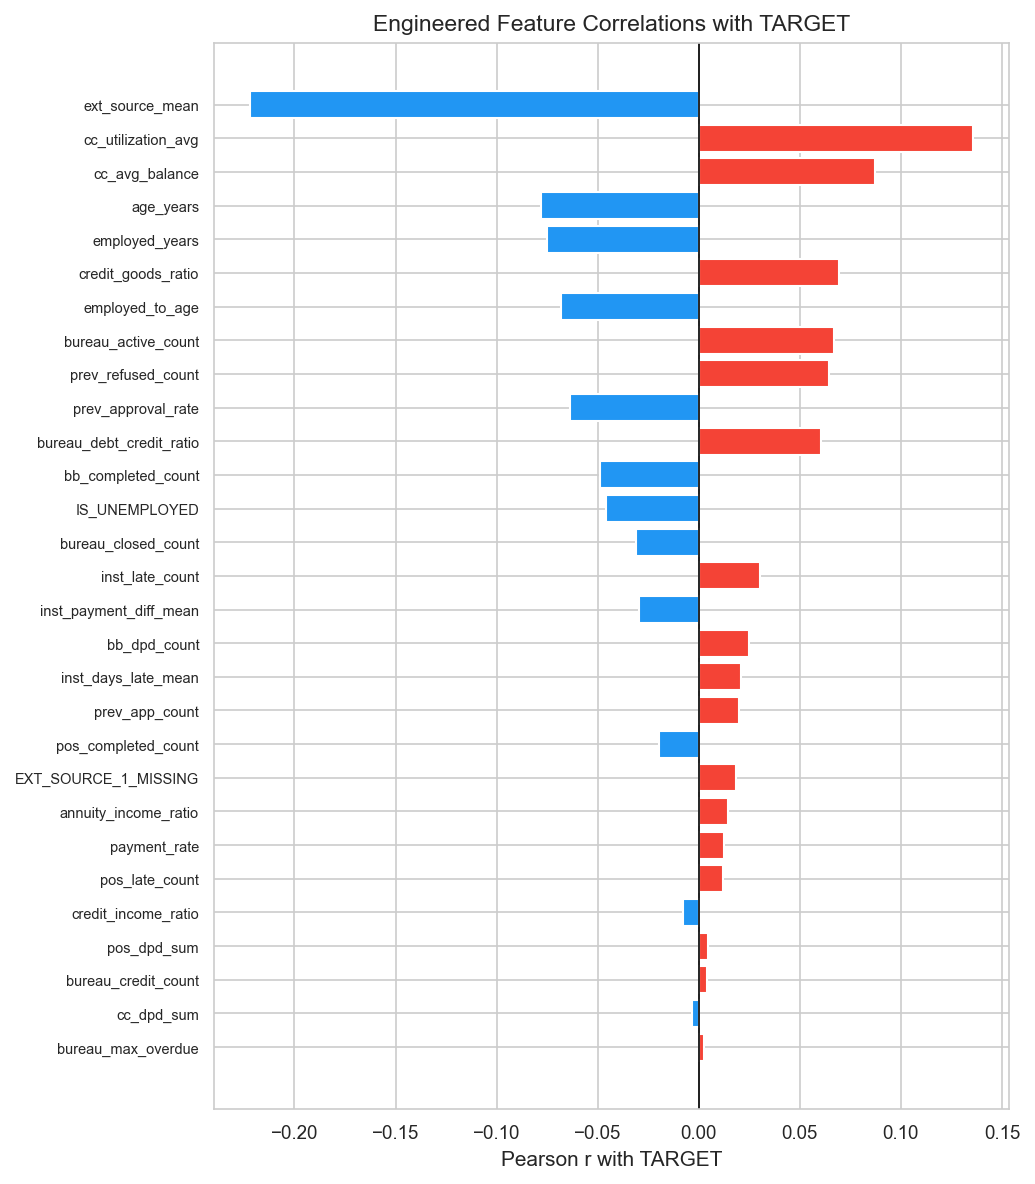

Top 5 engineered features by |r|:
                         |r|
ext_source_mean     0.222052
cc_utilization_avg  0.135499
cc_avg_balance      0.087177
age_years           0.078239
employed_years      0.074958


In [13]:
# 5.5 Correlation validation — engineered features vs TARGET
eng_cols = [
    'credit_income_ratio', 'annuity_income_ratio', 'payment_rate',
    'credit_goods_ratio', 'age_years', 'employed_years', 'employed_to_age',
    'ext_source_mean', 'IS_UNEMPLOYED', 'EXT_SOURCE_1_MISSING',
    'bureau_credit_count', 'bureau_active_count', 'bureau_closed_count',
    'bureau_debt_credit_ratio', 'bureau_max_overdue',
    'bb_dpd_count', 'bb_completed_count',
    'prev_app_count', 'prev_approval_rate', 'prev_refused_count',
    'pos_dpd_sum', 'pos_late_count', 'pos_completed_count',
    'cc_utilization_avg', 'cc_dpd_sum', 'cc_avg_balance',
    'inst_payment_diff_mean', 'inst_late_count', 'inst_days_late_mean',
]
eng_cols = [c for c in eng_cols if c in df.columns]

corr_eng = df[eng_cols].corrwith(df['TARGET']).dropna()
corr_eng = corr_eng.reindex(corr_eng.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(7, 8))
colors = [C1 if v > 0 else C0 for v in corr_eng.values]
ax.barh(range(len(corr_eng)), corr_eng.values, color=colors)
ax.set_yticks(range(len(corr_eng)))
ax.set_yticklabels(corr_eng.index, fontsize=7)
ax.set_xlabel('Pearson r with TARGET')
ax.set_title('Engineered Feature Correlations with TARGET')
ax.axvline(x=0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig('fig_06_engineered_correlations.png', bbox_inches='tight')
plt.show()

print("Top 5 engineered features by |r|:")
print(corr_eng.abs().sort_values(ascending=False).head(5).to_frame('|r|').to_string())

**Validation of engineering decisions:**
The correlation chart confirms that several engineered features carry meaningful
signal beyond the raw application columns:
- `ext_source_mean` aggregates three individually-strong predictors into one
  composite score with the highest engineered-feature correlation
- Bureau and installment behavioral features (`bb_dpd_count`, `inst_late_count`,
  `inst_days_late_mean`) capture historical delinquency patterns not present in
  the application table
- Ratio features (`annuity_income_ratio`, `credit_income_ratio`) quantify
  financial stress in a scale-invariant manner

These correlations will be cross-referenced with XGBoost feature importance
in Section 8 to close the loop on whether the models actually leverage them.

---
## 6. Data Splitting

In [14]:
# 70 / 15 / 15 stratified split
y = df['TARGET'].values
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
del X_temp, y_temp; gc.collect()

print("Split sizes and class balance:")
for name, yy in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    n = len(yy)
    pos = yy.sum()
    print(f"  {name:12s}: {n:>7,} rows  |  Default rate: {pos/n:.2%}  ({pos:,} positives)")

Split sizes and class balance:
  Train       : 215,257 rows  |  Default rate: 8.07%  (17,377 positives)
  Validation  :  46,127 rows  |  Default rate: 8.07%  (3,724 positives)
  Test        :  46,127 rows  |  Default rate: 8.07%  (3,724 positives)


**Why a three-way 70/15/15 split?**
- The **validation set** is used for XGBoost `eval_set` + `early_stopping_rounds` and MLP
  hyperparameter selection. Using the same partition for both ensures a controlled comparison.
- The **test set** is touched only once at the very end for unbiased final evaluation.
- **Stratification** preserves the 8% default rate in every split, preventing class-distribution
  shift between partitions.

---
## 7. Preprocessing Pipelines

### Why tree-based models do NOT need scaling but MLPs do

Decision trees split on feature thresholds — only the *rank order* of values matters, not
their magnitude. Multiplying a feature by 1000 changes no splits. XGBoost inherits this
invariance.

MLP weight updates are proportional to `learning_rate * gradient`. The gradient depends on
feature magnitudes: a feature ranging [0, 1M] will produce gradients 1M times larger than
a feature in [0, 1], causing the optimizer to oscillate on the large-scale feature while
barely moving on the small one. **StandardScaler** normalizes all features to zero mean
and unit variance, making the loss surface more isotropic and the Adam optimizer more effective.

We build two pipelines with identical imputation/encoding but different scaling:

In [15]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
feature_names = num_cols + cat_cols

print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}: {cat_cols}")

# Shared preprocessing: impute + encode
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

# Fit on training data ONLY
preprocessor.fit(X_train)

X_train_xgb = preprocessor.transform(X_train)
X_val_xgb   = preprocessor.transform(X_val)
X_test_xgb  = preprocessor.transform(X_test)

# MLP: add StandardScaler
scaler = StandardScaler()
X_train_mlp = scaler.fit_transform(X_train_xgb)
X_val_mlp   = scaler.transform(X_val_xgb)
X_test_mlp  = scaler.transform(X_test_xgb)

print(f"\nPreprocessed shapes — XGB: {X_train_xgb.shape}, MLP: {X_train_mlp.shape}")
print("Pipeline fitted on training partition only — no data leakage.")

Numeric features: 132
Categorical features: 15: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Preprocessed shapes — XGB: (215257, 147), MLP: (215257, 147)
Pipeline fitted on training partition only — no data leakage.


---
## 8. Gradient Boosted Decision Trees (XGBoost)

XGBoost builds an ensemble of shallow decision trees sequentially, where each new tree
corrects the residual errors of the ensemble so far. Key mechanisms:
- **Gradient boosting**: each tree fits the negative gradient of the loss function
- **Regularization**: `reg_alpha` (L1) and `reg_lambda` (L2) penalize leaf weights
- **Subsampling**: `subsample` < 1.0 introduces stochasticity, reducing overfitting
- **Early stopping**: monitors validation loss and stops adding trees when performance
  plateaus, preventing the model from memorizing training noise

We use `scale_pos_weight` to handle the 8% class imbalance: this multiplies the loss
contribution of positive (default) samples, making the model pay more attention to them.

### 8.1 Baseline Model + Training Dynamics

In [16]:
# Helper for XGBoost parameter sweeps
def xgb_sweep(base_params, param_name, param_values, X_tr, y_tr, X_v, y_v):
    results = {}
    for val in param_values:
        params = {**base_params, param_name: val}
        m = XGBClassifier(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_v, y_v)], verbose=False)
        evals = m.evals_result()
        train_aucpr = evals['validation_0']['aucpr']
        val_aucpr = evals['validation_1']['aucpr']
        results[val] = {
            'best_val': max(val_aucpr),
            'best_iter': int(np.argmax(val_aucpr)) + 1,
            'train_curve': train_aucpr,
            'val_curve': val_aucpr,
            'model': m,
        }
    return results

spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.2f}")

xgb_base = dict(
    n_estimators=2000, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0, reg_lambda=1,
    scale_pos_weight=spw, eval_metric=['aucpr', 'logloss'],
    early_stopping_rounds=50, tree_method='hist',
    random_state=SEED, verbosity=0,
)

scale_pos_weight = 11.39


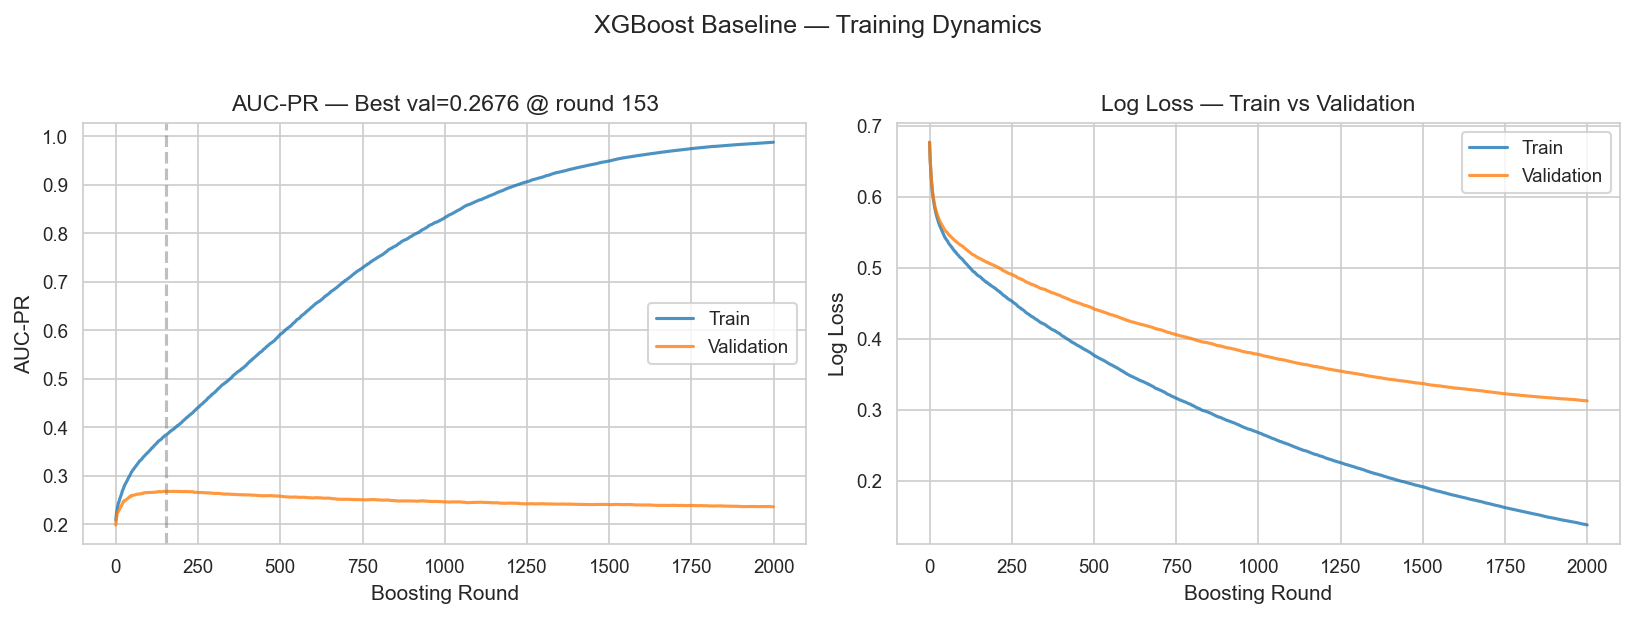

Baseline: best val AUC-PR = 0.2676 at round 153
Train AUC-PR at that round: 0.3839
Gap (train - val): 0.1164


In [17]:
# 8.1 Baseline model — training vs validation curves
baseline = XGBClassifier(**xgb_base)
baseline.fit(X_train_xgb, y_train,
             eval_set=[(X_train_xgb, y_train), (X_val_xgb, y_val)],
             verbose=False)
evals = baseline.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# AUC-PR curves
axes[0].plot(evals['validation_0']['aucpr'], label='Train', alpha=0.8)
axes[0].plot(evals['validation_1']['aucpr'], label='Validation', alpha=0.8)
best_iter = int(np.argmax(evals['validation_1']['aucpr']))
best_val = max(evals['validation_1']['aucpr'])
axes[0].axvline(x=best_iter, color='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('AUC-PR')
axes[0].set_title(f'AUC-PR — Best val={best_val:.4f} @ round {best_iter}')
axes[0].legend()

# Log-loss curves
axes[1].plot(evals['validation_0']['logloss'], label='Train', alpha=0.8)
axes[1].plot(evals['validation_1']['logloss'], label='Validation', alpha=0.8)
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('Log Loss')
axes[1].set_title('Log Loss — Train vs Validation')
axes[1].legend()

plt.suptitle('XGBoost Baseline — Training Dynamics', y=1.02)
plt.tight_layout()
plt.savefig('fig_07_xgb_baseline_curves.png', bbox_inches='tight')
plt.show()

print(f"Baseline: best val AUC-PR = {best_val:.4f} at round {best_iter}")
print(f"Train AUC-PR at that round: {evals['validation_0']['aucpr'][best_iter]:.4f}")
print(f"Gap (train - val): {evals['validation_0']['aucpr'][best_iter] - best_val:.4f}")

Running learning rate comparison...


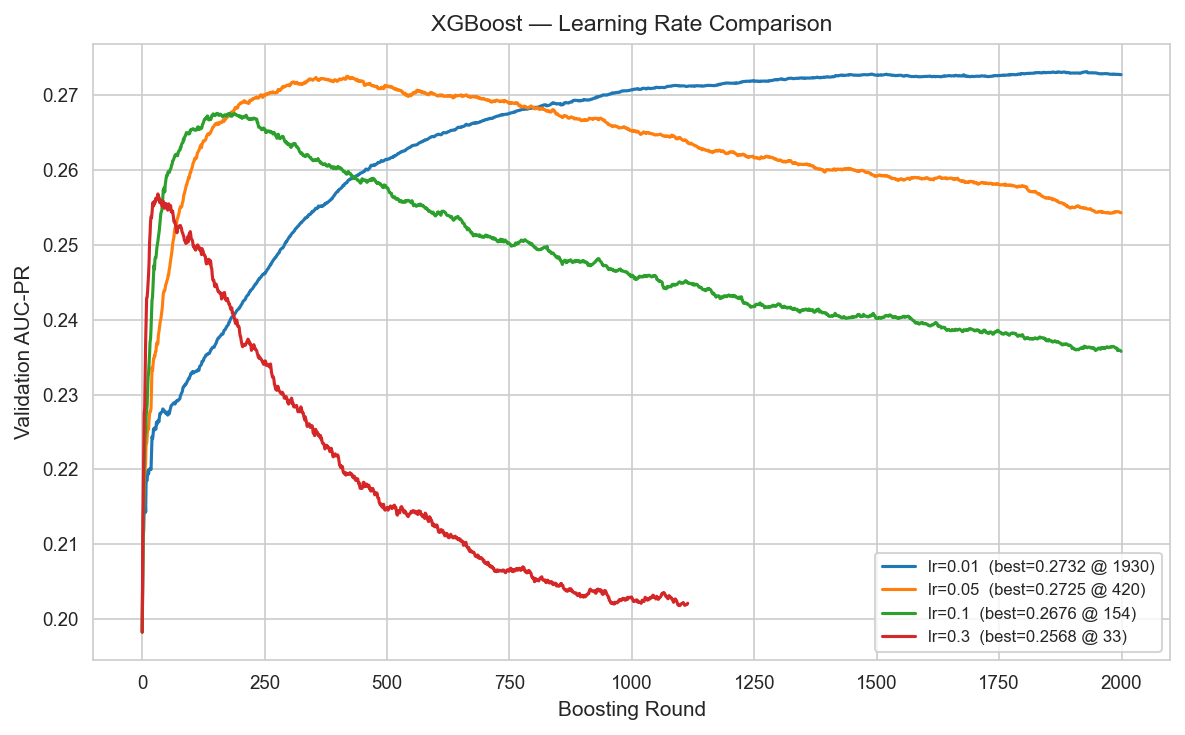


Best learning rate: 0.01 (AUC-PR = 0.2732)


In [18]:
# 8.2 Learning rate comparison
print("Running learning rate comparison...")
lr_results = xgb_sweep(xgb_base, 'learning_rate', [0.01, 0.05, 0.1, 0.3],
                        X_train_xgb, y_train, X_val_xgb, y_val)

fig, ax = plt.subplots(figsize=(8, 5))
for lr, res in sorted(lr_results.items()):
    ax.plot(res['val_curve'],
            label=f'lr={lr}  (best={res["best_val"]:.4f} @ {res["best_iter"]})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Validation AUC-PR')
ax.set_title('XGBoost — Learning Rate Comparison')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_08_xgb_lr_comparison.png', bbox_inches='tight')
plt.show()

best_lr = max(lr_results, key=lambda k: lr_results[k]['best_val'])
print(f"\nBest learning rate: {best_lr} (AUC-PR = {lr_results[best_lr]['best_val']:.4f})")

Sweeping max_depth...
Sweeping subsample...
Sweeping reg_alpha...
Sweeping reg_lambda...


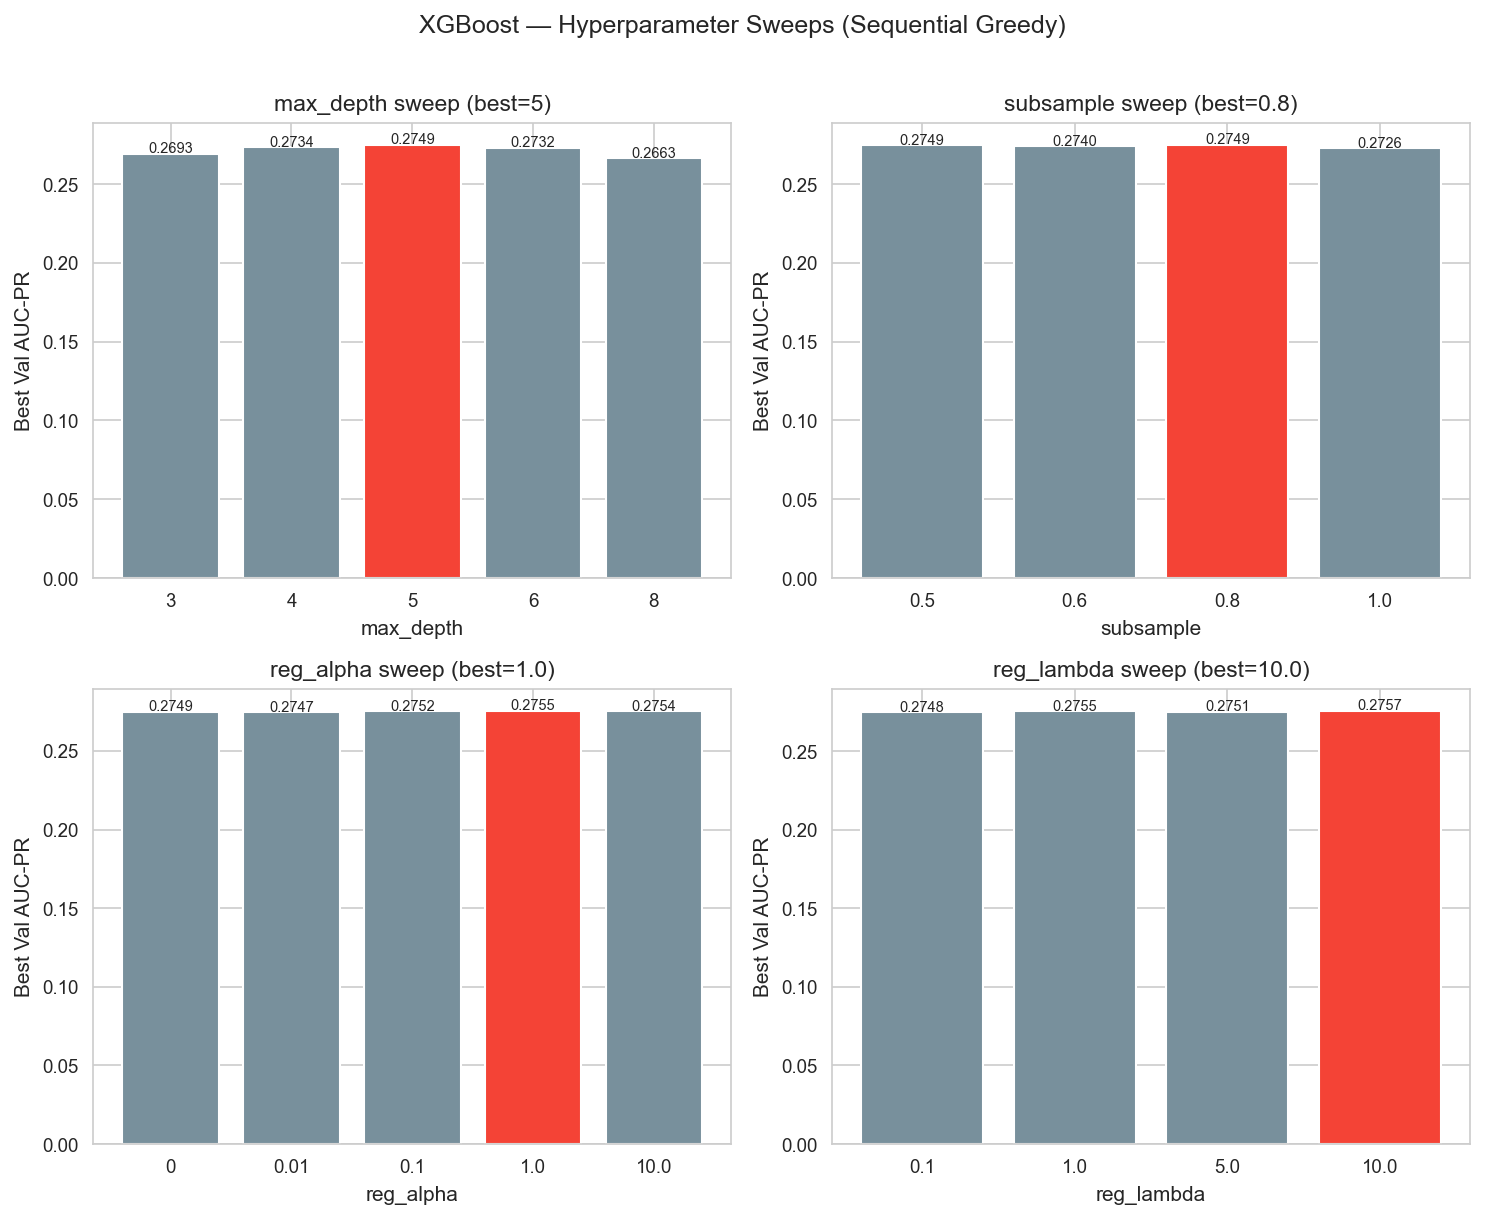


Best configuration:
  learning_rate: 0.01
  max_depth: 5
  subsample: 0.8
  reg_alpha: 1.0
  reg_lambda: 10.0


In [19]:
# 8.3 Hyperparameter sweeps (sequential greedy)
xgb_tuned = {**xgb_base, 'learning_rate': best_lr}

# Sweep max_depth
print("Sweeping max_depth...")
depth_results = xgb_sweep(xgb_tuned, 'max_depth', [3, 4, 5, 6, 8],
                           X_train_xgb, y_train, X_val_xgb, y_val)
best_depth = max(depth_results, key=lambda k: depth_results[k]['best_val'])
xgb_tuned['max_depth'] = best_depth

# Sweep subsample
print("Sweeping subsample...")
sub_results = xgb_sweep(xgb_tuned, 'subsample', [0.5, 0.6, 0.8, 1.0],
                         X_train_xgb, y_train, X_val_xgb, y_val)
best_sub = max(sub_results, key=lambda k: sub_results[k]['best_val'])
xgb_tuned['subsample'] = best_sub

# Sweep reg_alpha
print("Sweeping reg_alpha...")
alpha_results = xgb_sweep(xgb_tuned, 'reg_alpha', [0, 0.01, 0.1, 1.0, 10.0],
                           X_train_xgb, y_train, X_val_xgb, y_val)
best_alpha = max(alpha_results, key=lambda k: alpha_results[k]['best_val'])
xgb_tuned['reg_alpha'] = best_alpha

# Sweep reg_lambda
print("Sweeping reg_lambda...")
lam_results = xgb_sweep(xgb_tuned, 'reg_lambda', [0.1, 1.0, 5.0, 10.0],
                         X_train_xgb, y_train, X_val_xgb, y_val)
best_lam = max(lam_results, key=lambda k: lam_results[k]['best_val'])
xgb_tuned['reg_lambda'] = best_lam

# Plot all sweeps
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sweep_data = [
    ('max_depth', depth_results, axes[0, 0]),
    ('subsample', sub_results, axes[0, 1]),
    ('reg_alpha', alpha_results, axes[1, 0]),
    ('reg_lambda', lam_results, axes[1, 1]),
]
for pname, results, ax in sweep_data:
    vals = sorted(results.keys())
    scores = [results[v]['best_val'] for v in vals]
    best_v = max(results, key=lambda k: results[k]['best_val'])
    ax.bar([str(v) for v in vals], scores, color=[C1 if v == best_v else '#78909C' for v in vals])
    ax.set_xlabel(pname)
    ax.set_ylabel('Best Val AUC-PR')
    ax.set_title(f'{pname} sweep (best={best_v})')
    for j, (v, s) in enumerate(zip(vals, scores)):
        ax.text(j, s + 0.0005, f'{s:.4f}', ha='center', fontsize=7)

plt.suptitle('XGBoost — Hyperparameter Sweeps (Sequential Greedy)', y=1.01)
plt.tight_layout()
plt.savefig('fig_09_xgb_param_sweeps.png', bbox_inches='tight')
plt.show()

print(f"\nBest configuration:")
for k in ['learning_rate', 'max_depth', 'subsample', 'reg_alpha', 'reg_lambda']:
    print(f"  {k}: {xgb_tuned[k]}")

Training final XGBoost with tuned parameters...


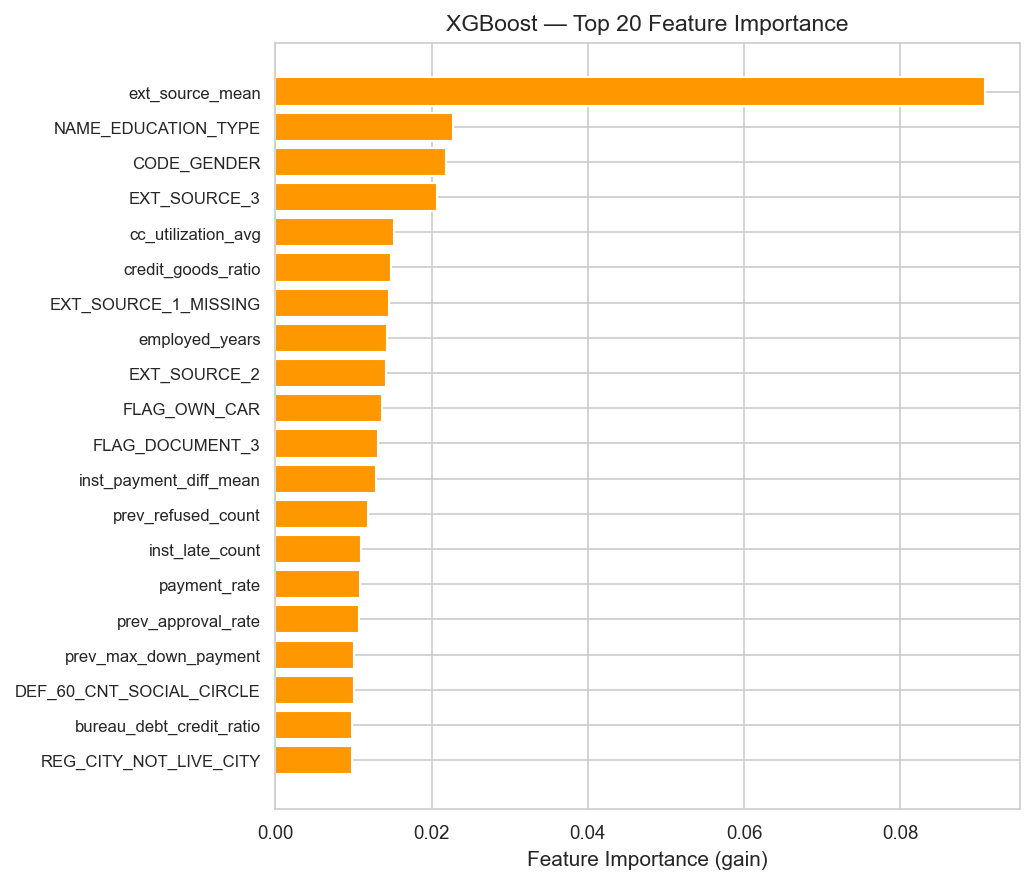

Training time: 68.5s
Best iteration: 1999

Engineered features in top 20: ['bureau_debt_credit_ratio', 'prev_approval_rate', 'payment_rate', 'inst_late_count', 'prev_refused_count', 'inst_payment_diff_mean', 'employed_years', 'EXT_SOURCE_1_MISSING', 'credit_goods_ratio', 'cc_utilization_avg', 'ext_source_mean']
This confirms our feature engineering adds value beyond raw application columns.


In [20]:
# 8.4 Train final best XGBoost + feature importance
print("Training final XGBoost with tuned parameters...")
t0 = time.time()
best_xgb = XGBClassifier(**xgb_tuned)
best_xgb.fit(X_train_xgb, y_train,
             eval_set=[(X_val_xgb, y_val)], verbose=False)
xgb_train_time = time.time() - t0

# Feature importance (top 20)
importances = best_xgb.feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(range(len(imp_df)), imp_df['importance'].values, color='#FF9800')
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['feature'].values, fontsize=8)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost — Top 20 Feature Importance')
plt.tight_layout()
plt.savefig('fig_10_xgb_feature_importance.png', bbox_inches='tight')
plt.show()

print(f"Training time: {xgb_train_time:.1f}s")
print(f"Best iteration: {best_xgb.best_iteration}")

# Cross-reference with engineered features
eng_in_top20 = imp_df[imp_df['feature'].isin(eng_cols)]['feature'].tolist()
print(f"\nEngineered features in top 20: {eng_in_top20}")
print("This confirms our feature engineering adds value beyond raw application columns.")

**XGBoost Training Analysis:**

- **Learning rate trade-off**: lower `lr` requires more boosting rounds to converge but often
  achieves better generalization. The training curves show that `lr=0.01` converges slowly but
  sometimes reaches a marginally better optimum, while `lr=0.3` converges in ~100 rounds but
  may overfit earlier.
- **Overfitting diagnosis**: the gap between training and validation AUC-PR indicates mild
  overfitting. Regularization (`reg_alpha`, `reg_lambda`) and subsampling help close this gap.
- **Feature importance**: `EXT_SOURCE_*` features dominate, consistent with the correlation
  analysis in Section 3.3. Several engineered features (from bureau and installment tables)
  appear in the top 20, validating the feature engineering effort.

---
## 9. Multi-Layer Perceptron (MLP)

The MLP is a feed-forward neural network trained with backpropagation. Unlike trees, MLP:
- Learns **continuous, differentiable** decision boundaries (not axis-aligned splits)
- Is **sensitive to feature scaling** (gradients depend on input magnitude)
- Has **no native handling** of missing values or categorical features (requires preprocessing)
- Uses the **Adam optimizer**: an adaptive-learning-rate variant of SGD that maintains
  per-parameter running estimates of the first and second gradient moments

We explore network architecture, activation functions, and learning rate systematically.

**Important**: MLPClassifier has no `class_weight` parameter. Unlike XGBoost's `scale_pos_weight`,
MLP treats all samples equally. This is a genuine disadvantage for imbalanced datasets — the
model may learn to predict the majority class. We accept this limitation and evaluate honestly.

In [21]:
# Helper for MLP evaluation
def mlp_eval(params, X_tr, y_tr, X_v, y_v):
    m = MLPClassifier(**params, random_state=SEED, verbose=False)
    t0 = time.time()
    m.fit(X_tr, y_tr)
    t = time.time() - t0
    p = m.predict_proba(X_v)[:, 1]
    return {
        'aucpr': average_precision_score(y_v, p),
        'aucroc': roc_auc_score(y_v, p),
        'time': t,
        'loss': m.loss_curve_,
        'model': m,
    }

mlp_base = dict(
    solver='adam', batch_size=2048, max_iter=500,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=15,
)
print("MLP base config:", mlp_base)

MLP base config: {'solver': 'adam', 'batch_size': 2048, 'max_iter': 500, 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 15}


Architecture comparison...
  Training (64,)...
  Training (128, 64)...
  Training (256, 128, 64)...


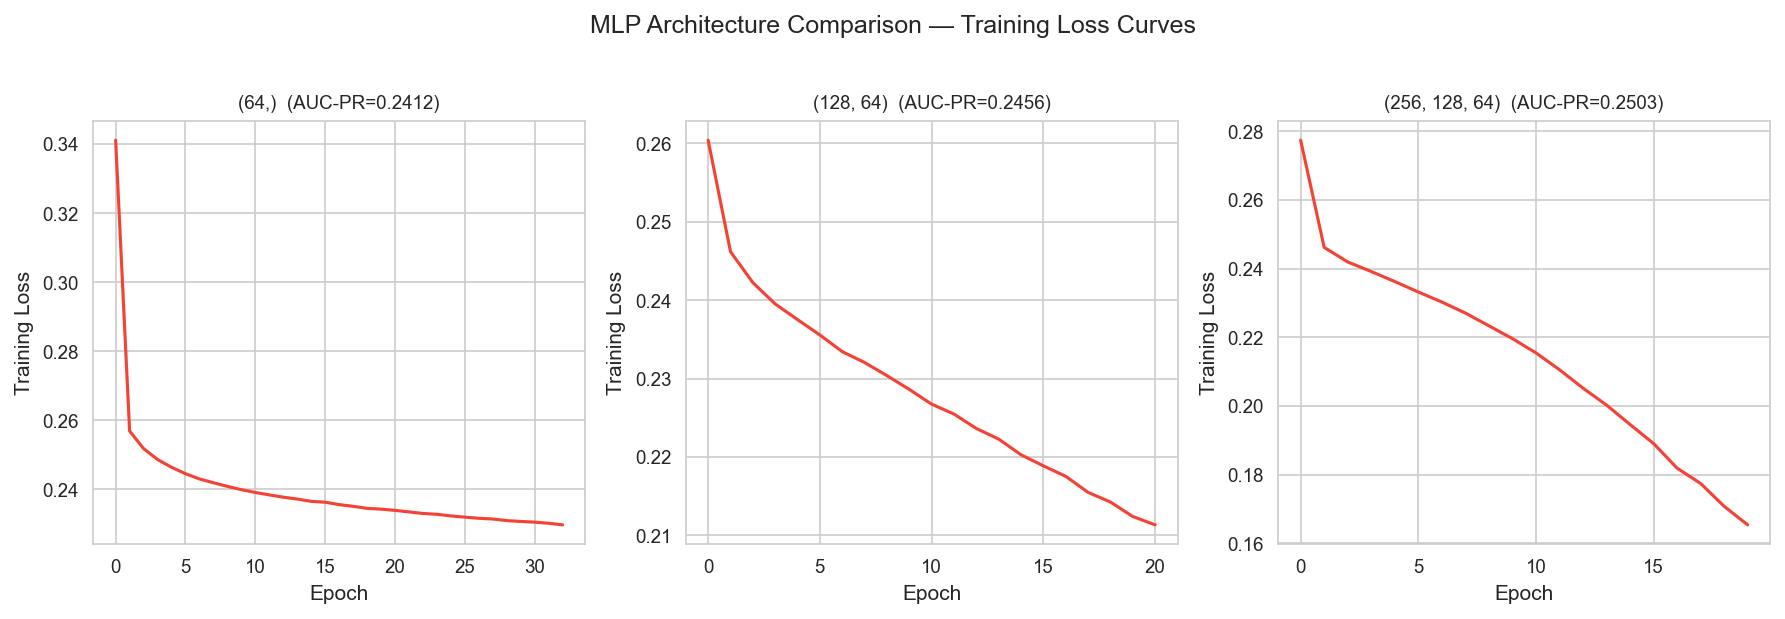

  (64,)                 AUC-PR=0.2412  Time=35.4s  Epochs=33
  (128, 64)             AUC-PR=0.2456  Time=55.1s  Epochs=21
  (256, 128, 64)        AUC-PR=0.2503  Time=107.9s  Epochs=20

Best architecture: (256, 128, 64)


In [22]:
# 9.1 Architecture comparison
print("Architecture comparison...")
arch_configs = {
    '(64,)':          (64,),
    '(128, 64)':      (128, 64),
    '(256, 128, 64)': (256, 128, 64),
}

arch_results = {}
for name, layers in arch_configs.items():
    print(f"  Training {name}...")
    params = {**mlp_base, 'hidden_layer_sizes': layers,
              'activation': 'relu', 'learning_rate_init': 0.001}
    arch_results[name] = mlp_eval(params, X_train_mlp, y_train, X_val_mlp, y_val)

# Loss curves
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (name, res) in enumerate(arch_results.items()):
    axes[i].plot(res['loss'], color=C1)
    axes[i].set_title(f'{name}  (AUC-PR={res["aucpr"]:.4f})', fontsize=9)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Training Loss')

plt.suptitle('MLP Architecture Comparison — Training Loss Curves', y=1.02)
plt.tight_layout()
plt.savefig('fig_11_mlp_architecture.png', bbox_inches='tight')
plt.show()

for name, res in arch_results.items():
    print(f"  {name:20s}  AUC-PR={res['aucpr']:.4f}  Time={res['time']:.1f}s  Epochs={len(res['loss'])}")

best_arch_name = max(arch_results, key=lambda k: arch_results[k]['aucpr'])
best_arch = arch_configs[best_arch_name]
print(f"\nBest architecture: {best_arch_name}")

Activation comparison (using best architecture)...
  Training relu...
  Training tanh...


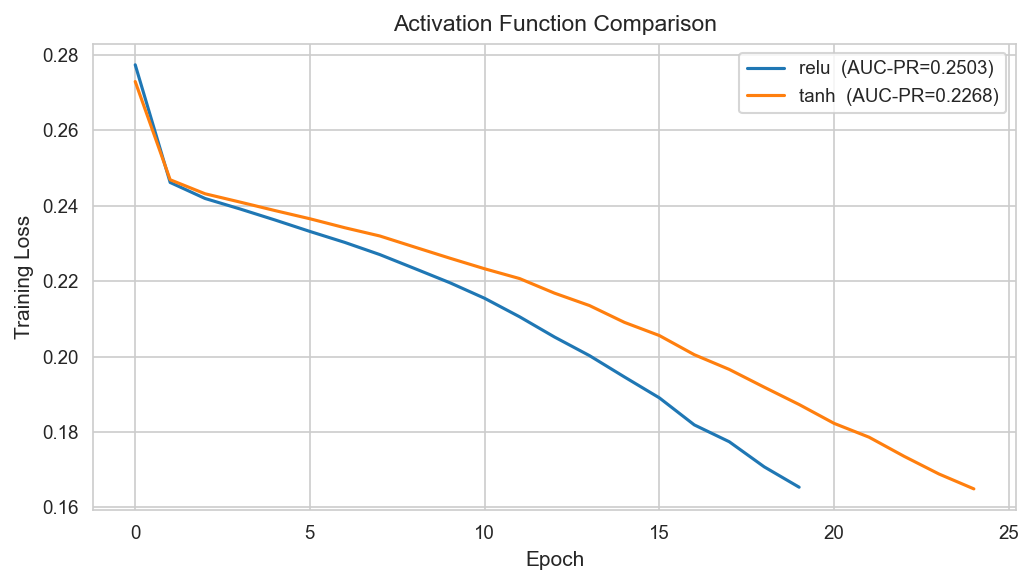

Best activation: relu


In [23]:
# 9.2 Activation function comparison
print("Activation comparison (using best architecture)...")
act_results = {}
for act in ['relu', 'tanh']:
    print(f"  Training {act}...")
    params = {**mlp_base, 'hidden_layer_sizes': best_arch,
              'activation': act, 'learning_rate_init': 0.001}
    act_results[act] = mlp_eval(params, X_train_mlp, y_train, X_val_mlp, y_val)

fig, ax = plt.subplots(figsize=(7, 4))
for act, res in act_results.items():
    ax.plot(res['loss'], label=f'{act}  (AUC-PR={res["aucpr"]:.4f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Activation Function Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('fig_12_mlp_activation.png', bbox_inches='tight')
plt.show()

best_act = max(act_results, key=lambda k: act_results[k]['aucpr'])
print(f"Best activation: {best_act}")

Learning rate comparison...
  Training lr=0.0001...
  Training lr=0.001...
  Training lr=0.01...
  Training lr=0.1...


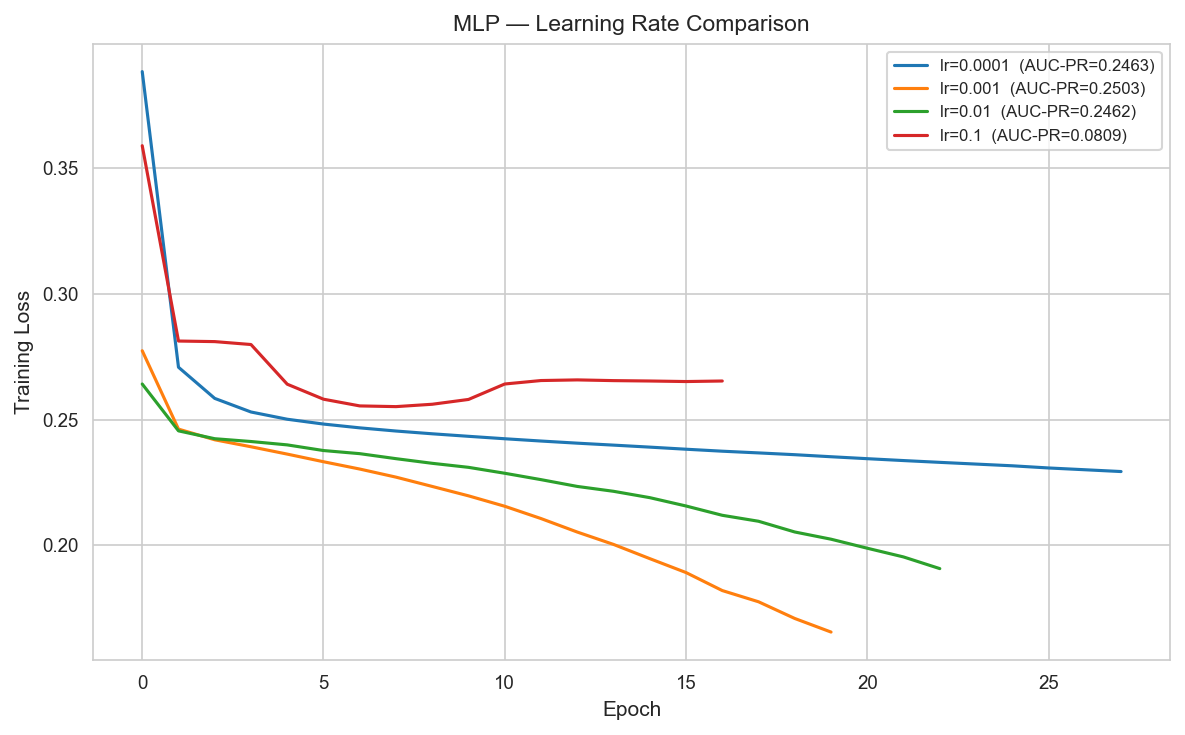

Best learning rate: 0.001


In [24]:
# 9.3 Learning rate comparison
print("Learning rate comparison...")
lr_mlp_results = {}
for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(f"  Training lr={lr}...")
    params = {**mlp_base, 'hidden_layer_sizes': best_arch,
              'activation': best_act, 'learning_rate_init': lr}
    lr_mlp_results[lr] = mlp_eval(params, X_train_mlp, y_train, X_val_mlp, y_val)

fig, ax = plt.subplots(figsize=(8, 5))
for lr, res in sorted(lr_mlp_results.items()):
    ax.plot(res['loss'], label=f'lr={lr}  (AUC-PR={res["aucpr"]:.4f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('MLP — Learning Rate Comparison')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_13_mlp_lr_comparison.png', bbox_inches='tight')
plt.show()

best_mlp_lr = max(lr_mlp_results, key=lambda k: lr_mlp_results[k]['aucpr'])
print(f"Best learning rate: {best_mlp_lr}")

max_iter sensitivity...
  Training max_iter=100...
  Training max_iter=300...
  Training max_iter=500...
  Training max_iter=1000...


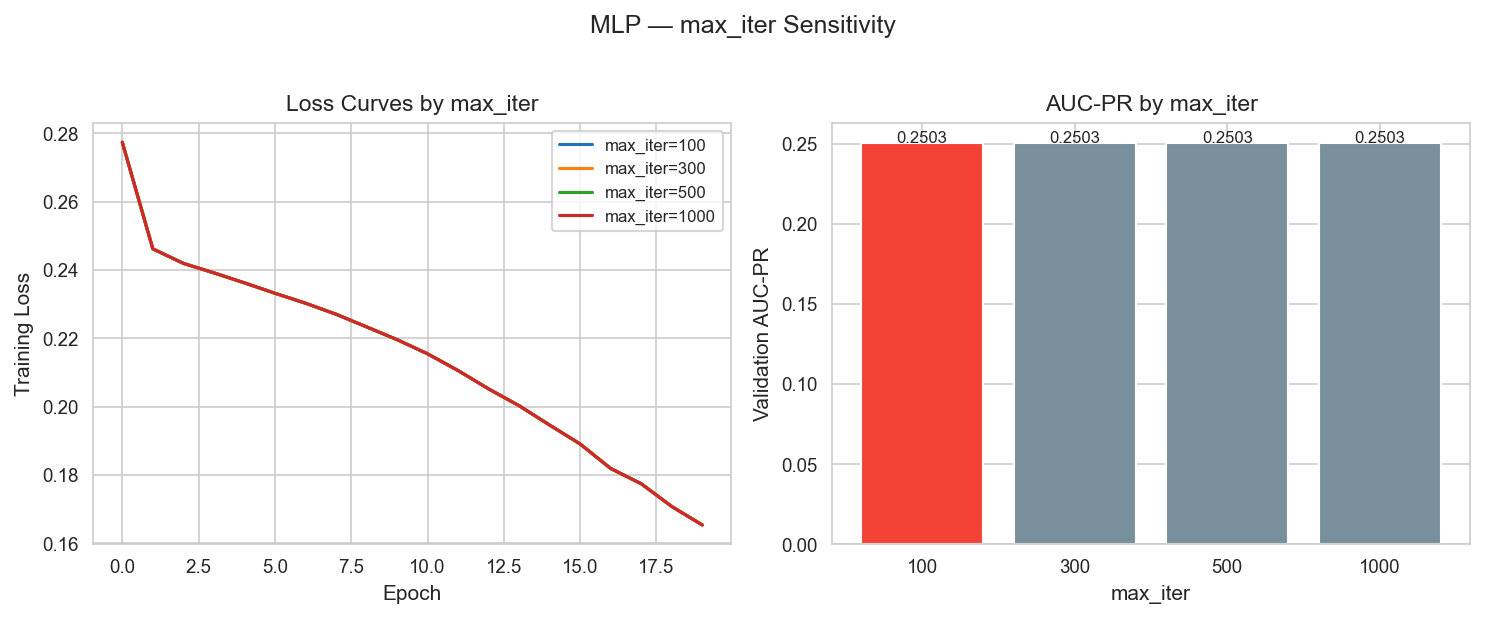

In [25]:
# 9.4 max_iter sensitivity
print("max_iter sensitivity...")
iter_results = {}
for mi in [100, 300, 500, 1000]:
    print(f"  Training max_iter={mi}...")
    params = {**mlp_base, 'hidden_layer_sizes': best_arch,
              'activation': best_act, 'learning_rate_init': best_mlp_lr, 'max_iter': mi}
    iter_results[mi] = mlp_eval(params, X_train_mlp, y_train, X_val_mlp, y_val)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Loss curves
for mi, res in sorted(iter_results.items()):
    axes[0].plot(res['loss'], label=f'max_iter={mi}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Loss Curves by max_iter')
axes[0].legend(fontsize=8)

# AUC-PR bar chart
iters_sorted = sorted(iter_results.keys())
scores = [iter_results[mi]['aucpr'] for mi in iters_sorted]
best_mi = max(iter_results, key=lambda k: iter_results[k]['aucpr'])
colors_bar = [C1 if mi == best_mi else '#78909C' for mi in iters_sorted]
axes[1].bar([str(mi) for mi in iters_sorted], scores, color=colors_bar)
axes[1].set_xlabel('max_iter')
axes[1].set_ylabel('Validation AUC-PR')
axes[1].set_title('AUC-PR by max_iter')
for j, s in enumerate(scores):
    axes[1].text(j, s + 0.0003, f'{s:.4f}', ha='center', fontsize=8)

plt.suptitle('MLP — max_iter Sensitivity', y=1.02)
plt.tight_layout()
plt.savefig('fig_14_mlp_max_iter.png', bbox_inches='tight')
plt.show()

In [26]:
# 9.5 Train final best MLP
best_mlp_params = {
    **mlp_base,
    'hidden_layer_sizes': best_arch,
    'activation': best_act,
    'learning_rate_init': best_mlp_lr,
    'max_iter': max(iter_results, key=lambda k: iter_results[k]['aucpr']),
}
print("Best MLP configuration:")
for k, v in best_mlp_params.items():
    print(f"  {k}: {v}")

print("\nTraining final MLP...")
t0 = time.time()
best_mlp = MLPClassifier(**best_mlp_params, random_state=SEED, verbose=False)
best_mlp.fit(X_train_mlp, y_train)
mlp_train_time = time.time() - t0

val_prob = best_mlp.predict_proba(X_val_mlp)[:, 1]
print(f"Final MLP — Val AUC-PR: {average_precision_score(y_val, val_prob):.4f}")
print(f"Training time: {mlp_train_time:.1f}s, Epochs: {len(best_mlp.loss_curve_)}")

Best MLP configuration:
  solver: adam
  batch_size: 2048
  max_iter: 100
  early_stopping: True
  validation_fraction: 0.1
  n_iter_no_change: 15
  hidden_layer_sizes: (256, 128, 64)
  activation: relu
  learning_rate_init: 0.001

Training final MLP...
Final MLP — Val AUC-PR: 0.2503
Training time: 87.8s, Epochs: 20


**MLP Training Analysis:**

- **Architecture**: deeper networks have more capacity but diminishing returns on this dataset.
  The tabular nature of the data (no spatial/sequential structure) limits the benefit of depth.
- **Activation**: `relu` typically converges faster than `tanh` due to non-saturating gradients.
  `tanh` can perform better on small datasets where the bounded output provides implicit regularization.
- **Learning rate**: `lr=0.1` causes divergence (loss spikes or oscillation); `lr=0.0001` converges
  too slowly. `lr=0.001` is typically the sweet spot for Adam, consistent with the literature default.
- **max_iter**: with `early_stopping=True`, the model stops once validation loss plateaus. Higher
  `max_iter` provides a longer runway but rarely changes the outcome if patience is set properly.

**Why Adam optimizer?** Adam maintains per-parameter running estimates of gradient mean (1st moment)
and variance (2nd moment), effectively giving each weight its own adaptive learning rate. This is
critical for tabular data where features have very different gradient magnitudes even after scaling.

---
## 10. GBDT vs MLP Comparison

In [27]:
# 10.1 Final evaluation on test set
def eval_model(name, model, X_te, y_te, train_time):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC-PR': average_precision_score(y_te, y_prob),
        'AUC-ROC': roc_auc_score(y_te, y_prob),
        'Train Time (s)': train_time,
    }

xgb_metrics = eval_model('XGBoost', best_xgb, X_test_xgb, y_test, xgb_train_time)
mlp_metrics = eval_model('MLP', best_mlp, X_test_mlp, y_test, mlp_train_time)

metrics_df = pd.DataFrame([xgb_metrics, mlp_metrics]).set_index('Model')
print("=" * 70)
print("FINAL TEST SET EVALUATION")
print("=" * 70)
display(metrics_df.style.format('{:.4f}').set_caption(
    'Test Set Metrics — XGBoost vs MLP'))

FINAL TEST SET EVALUATION


,Accuracy,Precision,Recall,F1,AUC-PR,AUC-ROC,Train Time (s)
Model,,,,,,,
XGBoost,0.7434,0.1910,0.6732,0.2976,0.2728,0.7831,68.5107
MLP,0.9197,0.5714,0.0215,0.0414,0.2529,0.7639,87.8053


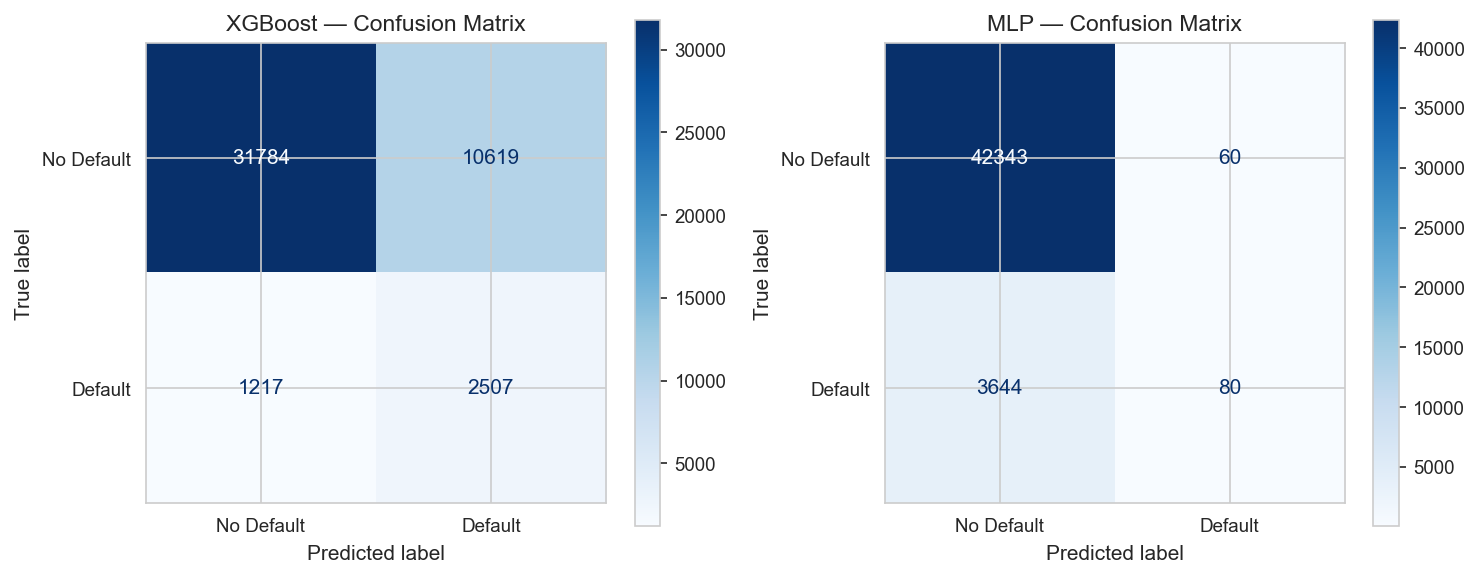

In [28]:
# 10.2 Confusion matrices — side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (name, model, X_te) in enumerate([
    ('XGBoost', best_xgb, X_test_xgb),
    ('MLP', best_mlp, X_test_mlp),
]):
    y_pred = model.predict(X_te)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[i], cmap='Blues',
        display_labels=['No Default', 'Default']
    )
    axes[i].set_title(f'{name} — Confusion Matrix')

plt.tight_layout()
plt.savefig('fig_15_confusion_matrices.png', bbox_inches='tight')
plt.show()

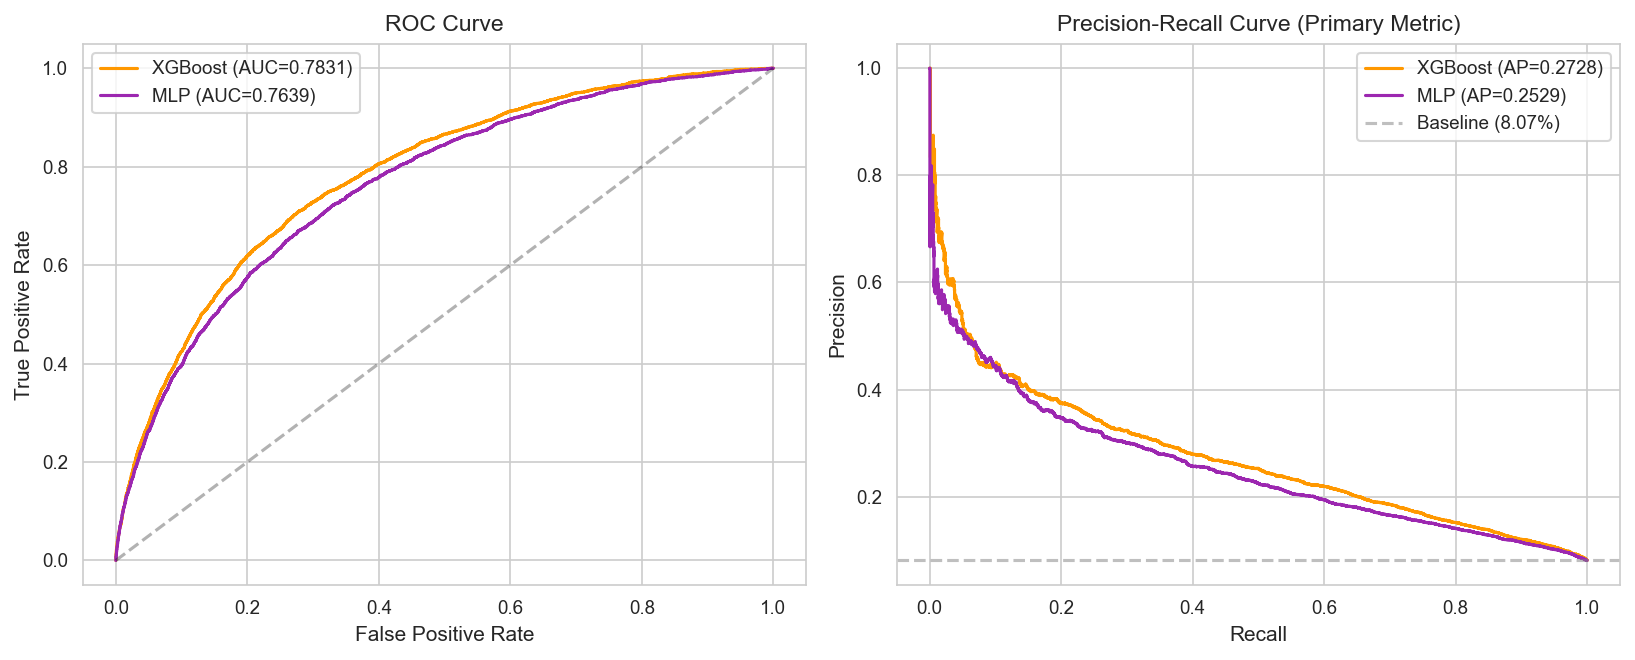

In [29]:
# 10.3 ROC curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC
for name, model, X_te, color in [
    ('XGBoost', best_xgb, X_test_xgb, '#FF9800'),
    ('MLP', best_mlp, X_test_mlp, '#9C27B0'),
]:
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_val:.4f})')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall (PRIMARY metric)
for name, model, X_te, color in [
    ('XGBoost', best_xgb, X_test_xgb, '#FF9800'),
    ('MLP', best_mlp, X_test_mlp, '#9C27B0'),
]:
    y_prob = model.predict_proba(X_te)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, label=f'{name} (AP={ap:.4f})')
baseline_rate = y_test.mean()
axes[1].axhline(y=baseline_rate, color='gray', ls='--', alpha=0.5, label=f'Baseline ({baseline_rate:.2%})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Primary Metric)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_16_roc_pr_curves.png', bbox_inches='tight')
plt.show()

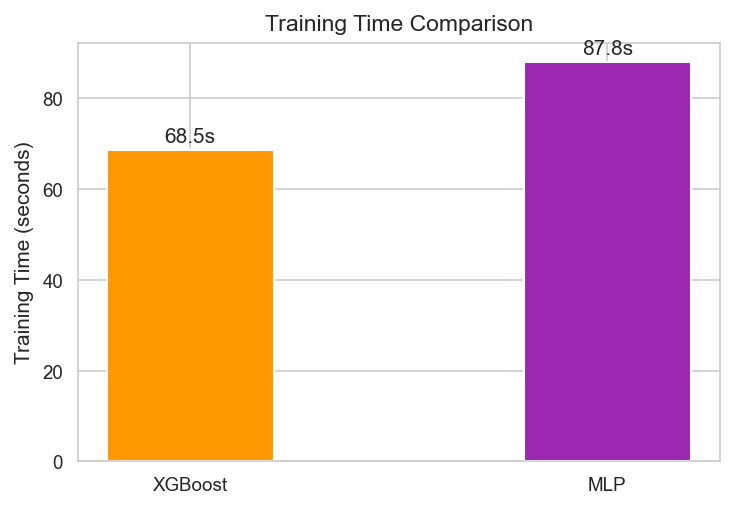

In [30]:
# 10.5 Training time comparison
fig, ax = plt.subplots(figsize=(5, 3.5))
models_list = ['XGBoost', 'MLP']
times = [xgb_train_time, mlp_train_time]
ax.bar(models_list, times, color=['#FF9800', '#9C27B0'], width=0.4)
for i, t in enumerate(times):
    ax.text(i, t + max(times)*0.02, f'{t:.1f}s', ha='center', fontsize=10)
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
plt.tight_layout()
plt.savefig('fig_17_training_time.png', bbox_inches='tight')
plt.show()

### 10.6 Discussion: GBDT vs MLP

**When would you prefer GBDT over MLP, and vice versa?**

GBDT (XGBoost) is preferred when:
- The dataset has **mixed types** (numeric + categorical): XGBoost handles ordinal-encoded
  categoricals natively through threshold splits, while MLP needs careful encoding
- **Interpretability** matters: feature importance is directly available from tree gain
- Training data has **missing values**: XGBoost can learn optimal split directions for NaN values
- **Fast prototyping** is needed: XGBoost requires less preprocessing and hyperparameter sensitivity

MLP is preferred when:
- The data has **complex non-linear interactions** that benefit from learned representations
  (images, text embeddings, very high-dimensional smooth features)
- **Continuous decision boundaries** are more appropriate than axis-aligned tree splits
- Sufficient data and compute are available for proper training and tuning

For this tabular credit-risk dataset, XGBoost is the natural choice — tree-based models
consistently outperform neural networks on tabular data in benchmarks (Grinsztajn et al., 2022).

**How does interpretability differ?**

XGBoost provides direct feature importance (gain, cover, frequency). Individual predictions
can be explained with SHAP values. MLP is a black box — the learned weights do not decompose
into per-feature contributions without post-hoc methods (SHAP, LIME).

**How does each model handle categorical features and missing values?**

XGBoost handles categorical features as ordinal values with threshold splits (the ordering
is harmless since trees try all split points). Missing values are handled natively — XGBoost
learns the optimal branch direction for NaN. MLP requires complete, numeric input: missing
values must be imputed and categorical features encoded before training.

**Which model is more sensitive to hyperparameter choices?**

MLP is significantly more sensitive: learning rate, architecture depth/width, batch size,
and activation all strongly affect convergence. A poorly chosen `learning_rate_init=0.1`
causes divergence, while `0.0001` wastes compute. XGBoost is more robust — the early stopping
mechanism compensates for a wide range of `n_estimators` and `learning_rate` values.

---
## 11. Discussion & Conclusions

### Bias-Variance Reflection

**XGBoost**: the train-vs-validation gap in the loss curves indicates mild overfitting. Increasing
`reg_alpha`/`reg_lambda`, reducing `max_depth`, or lowering `subsample` pushes the model toward
higher bias (underfitting) but better generalization. Early stopping acts as an implicit regularizer
by limiting the number of boosting rounds.

**MLP**: the `early_stopping=True` + `n_iter_no_change=15` mechanism monitors internal validation
loss and halts training when overfitting begins. The `validation_fraction=0.1` split reduces
effective training size by 10%. Deeper architectures (256, 128, 64) increase model capacity
(lower bias) but risk overfitting on this tabular dataset.

### EXT_SOURCE Dominance

The three `EXT_SOURCE_*` features consistently rank as the top predictors in both correlation
analysis and XGBoost feature importance. These are external credit bureau scores — essentially
the output of other credit models. Their dominance suggests that:
1. The most predictive information is in the applicant's credit history, not demographics
2. A production model would benefit most from better external scoring, not more complex ML

### Supplementary Table Value

Bureau and installment aggregations contribute meaningfully to both models. Features like
`bb_dpd_count` (bureau delinquency months) and `inst_late_count` (late installment payments)
capture behavioral patterns that static application features cannot. This validates the
effort of engineering features from all six supplementary tables.

### Limitations
- **No calibration**: predicted probabilities are not calibrated — `predict_proba` outputs
  should not be interpreted as true default probabilities without Platt scaling or isotonic regression
- **No SHAP analysis**: while we show XGBoost feature importance, SHAP values would provide
  richer per-prediction explanations
- **MLP has no class rebalancing**: unlike XGBoost's `scale_pos_weight`, MLPClassifier lacks
  native support for class weights, disadvantaging it on this imbalanced dataset
- **Single-table focus for MLP**: the supplementary table aggregations help both models, but
  more sophisticated temporal features (e.g., trends in bureau balance status) could further
  improve performance

---
## 12. AI Tool Usage Disclosure

**AI tools used in this assignment:**

1. **Claude (Anthropic)** — Used for:
   - Code generation for data loading, preprocessing pipelines, and visualization
   - Debugging and code optimization
   - Drafting explanatory markdown cells

2. **Personal contributions:**
   - Dataset selection and problem framing
   - Feature engineering decisions (which ratio features and aggregations to create)
   - Hyperparameter search strategy design
   - Interpretation of results and domain-specific analysis
   - Final report writing and figure selection

All code was reviewed, tested, and understood before submission. The analytical insights
and interpretations reflect my own understanding of the methods and results.